# Import Libraries & Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\ijish\\Downloads\\telcom_data (2).xlsx - Sheet1.csv")

# Understanding & Cleaning the Dataset

In [3]:
df.head()

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,1.311450e+19,4/4/19 12:01,770.0,4/25/19 14:35,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9.16457E+15,...,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,1.311450e+19,4/9/19 13:04,235.0,4/25/19 8:15,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,1.311450e+19,4/9/19 17:42,1.0,4/25/19 11:58,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,1.311450e+19,4/10/19 0:31,486.0,4/25/19 7:36,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,1.311450e+19,4/12/19 20:10,565.0,4/25/19 10:40,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


In [4]:
df.shape

(150001, 55)

# Dataset Overview

The dataset connsists of 150001 records and 55 features, providing a detailed information about telecommunication sessions, customer activity, network perfomance and application usage.
+ Source: TellCo telecommunications xDR data
+ Period: One month of aggregated data
+ Record type: Data-session/xDR records
+ Focus: Customer activity and mobile data usage
+ Customer identifier: MSISDN/Number
+ Key areas: Handset, sessions, duration, traffic, network performance and application usage
+ Applications: Social Media, Google, Email, YouTube, Netflix, Gaming and Other
+ Analysis level: Session-level analysis followed by customer-level aggregation
+ Objective: Understand user behavior and identify opportunities for customer engagement, service improvement and business growth

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   Bearer Id                                 149010 non-null  float64
 1   Start                                     150000 non-null  object 
 2   Start ms                                  150000 non-null  float64
 3   End                                       150000 non-null  object 
 4   End ms                                    150000 non-null  float64
 5   Dur. (ms)                                 150000 non-null  float64
 6   IMSI                                      149431 non-null  float64
 7   MSISDN/Number                             148935 non-null  float64
 8   IMEI                                      149429 non-null  float64
 9   Last Location Name                        148848 non-null  object 
 10  Avg RTT DL (ms)     

In [6]:
df.columns.tolist()

['Bearer Id',
 'Start',
 'Start ms',
 'End',
 'End ms',
 'Dur. (ms)',
 'IMSI',
 'MSISDN/Number',
 'IMEI',
 'Last Location Name',
 'Avg RTT DL (ms)',
 'Avg RTT UL (ms)',
 'Avg Bearer TP DL (kbps)',
 'Avg Bearer TP UL (kbps)',
 'TCP DL Retrans. Vol (Bytes)',
 'TCP UL Retrans. Vol (Bytes)',
 'DL TP < 50 Kbps (%)',
 '50 Kbps < DL TP < 250 Kbps (%)',
 '250 Kbps < DL TP < 1 Mbps (%)',
 'DL TP > 1 Mbps (%)',
 'UL TP < 10 Kbps (%)',
 '10 Kbps < UL TP < 50 Kbps (%)',
 '50 Kbps < UL TP < 300 Kbps (%)',
 'UL TP > 300 Kbps (%)',
 'HTTP DL (Bytes)',
 'HTTP UL (Bytes)',
 'Activity Duration DL (ms)',
 'Activity Duration UL (ms)',
 'Dur. (ms).1',
 'Handset Manufacturer',
 'Handset Type',
 'Nb of sec with 125000B < Vol DL',
 'Nb of sec with 1250B < Vol UL < 6250B',
 'Nb of sec with 31250B < Vol DL < 125000B',
 'Nb of sec with 37500B < Vol UL',
 'Nb of sec with 6250B < Vol DL < 31250B',
 'Nb of sec with 6250B < Vol UL < 37500B',
 'Nb of sec with Vol DL < 6250B',
 'Nb of sec with Vol UL < 1250B',
 'Socia

# Dataset Features

The dataset contains telecommunication xDR session level data covering customer activity, network perfomance, application usage and device identification.

Main Feature Categories are:
+ Customer & Device Identification - MSISDN, IMSI, IMEI, Bearer ID.
+ Session & Time Information - Start/End time and session duration.
+ Network Information - AvgRTT DL/UL, Avg BearerTP DL/UL, TCP retransmission.
+ Throughput Distribution - Dl Tp <50 Kbps(%), 50Kbps < DL TP < 250Kbps(%), etc.
+ Traffic Data - Total DL(Bytes), Total UL(Bytes).
+ Application Usage - Social Media, Youtube, Netflix, Google, Email, Gaming and Other data usage.
+ Hnadset Information - Handset Type, Handset Manufacturer.
+ Additional Network / Application Metrics - HTTP DL/UL, Activity Duration DL/UL, application Specific DL/UL.

In [7]:
df.describe()

,Bearer Id,Start ms,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
count,1.490100e+05,150000.000000,150000.000000,1.500000e+05,1.494310e+05,1.489350e+05,1.494290e+05,122172.000000,122189.000000,150000.000000,...,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500000e+05,1.500000e+05
mean,1.013887e+19,499.188200,498.800880,1.046086e+05,2.082016e+14,4.188282e+10,4.847455e+13,109.795706,17.662883,13300.045927,...,1.163407e+07,1.100941e+07,1.162685e+07,1.100175e+07,4.220447e+08,8.288398e+06,4.211005e+08,8.264799e+06,4.112121e+07,4.546434e+08
std,2.893170e+18,288.611834,288.097653,8.103762e+04,2.148809e+10,2.447443e+12,2.241637e+13,619.782739,84.793524,23971.878541,...,6.710569e+06,6.345423e+06,6.725218e+06,6.359490e+06,2.439675e+08,4.782700e+06,2.432050e+08,4.769004e+06,1.127639e+07,2.441429e+08
min,6.917540e+18,0.000000,0.000000,7.142000e+03,2.040471e+14,3.360100e+10,4.400152e+11,0.000000,0.000000,0.000000,...,5.300000e+01,1.050000e+02,4.200000e+01,3.500000e+01,2.516000e+03,5.900000e+01,3.290000e+03,1.480000e+02,2.866892e+06,7.114041e+06
25%,7.349880e+18,250.000000,251.000000,5.744050e+04,2.082014e+14,3.365130e+10,3.546071e+13,32.000000,2.000000,43.000000,...,5.833501e+06,5.517965e+06,5.777156e+06,5.475981e+06,2.104733e+08,4.128476e+06,2.101869e+08,4.145943e+06,3.322201e+07,2.431068e+08
50%,7.349880e+18,499.000000,500.000000,8.639900e+04,2.082015e+14,3.366371e+10,3.572201e+13,45.000000,5.000000,63.000000,...,1.161602e+07,1.101345e+07,1.164222e+07,1.099638e+07,4.234081e+08,8.291208e+06,4.218030e+08,8.267071e+06,4.114331e+07,4.558411e+08
75%,1.304240e+19,749.000000,750.000000,1.324302e+05,2.082018e+14,3.368349e+10,8.611970e+13,70.000000,15.000000,19710.750000,...,1.744852e+07,1.651556e+07,1.747048e+07,1.650727e+07,6.331742e+08,1.243162e+07,6.316918e+08,1.238415e+07,4.903424e+07,6.657055e+08
max,1.318650e+19,999.000000,999.000000,1.859336e+06,2.140743e+14,8.823971e+14,9.900120e+13,96923.000000,7120.000000,378160.000000,...,2.325910e+07,2.201196e+07,2.325919e+07,2.201196e+07,8.434419e+08,1.655879e+07,8.434425e+08,1.655882e+07,7.833131e+07,9.029696e+08


## Handling Missing Values

In [8]:
df.isnull().sum()

Bearer Id                                      991
Start                                            1
Start ms                                         1
End                                              1
End ms                                           1
Dur. (ms)                                        1
IMSI                                           570
MSISDN/Number                                 1066
IMEI                                           572
Last Location Name                            1153
Avg RTT DL (ms)                              27829
Avg RTT UL (ms)                              27812
Avg Bearer TP DL (kbps)                          1
Avg Bearer TP UL (kbps)                          1
TCP DL Retrans. Vol (Bytes)                  88146
TCP UL Retrans. Vol (Bytes)                  96649
DL TP < 50 Kbps (%)                            754
50 Kbps < DL TP < 250 Kbps (%)                 754
250 Kbps < DL TP < 1 Mbps (%)                  754
DL TP > 1 Mbps (%)             

### Insights
+ Several important identification fields have missing values.
MSISDN/Number has 1,066 missing values, while IMSI has 570 and IMEI has 572 missing values. These fields are important for customer-level aggregation and device analysis.
+ Network performance variables have substantial missing values.
Avg RTT DL (ms) and Avg RTT UL (ms) have approximately 27,800 missing values each. This is significant because RTT is required for the User Experience analysis.
+ TCP retransmission variables and HTTP traffic variables contains large number of missing values.
TCP DL Retrans. Vol (Bytes) has 88,146 missing values and TCP UL Retrans. Vol (Bytes) has 96,649 missing values, HTTP DL (Bytes) has 81,474 missing values and HTTP UL (Bytes) has 81,810 missing values.These variables therefore require careful treatment before analyzing network reliability.
+ The download throughput distribution variables have 754 missing values each, while the upload throughput variables have approximately 792 missing values each. These are comparatively smaller amounts of missing data.
+Some activity and traffic variables have almost no missing values.
Start, End, Dur. (ms), Avg Bearer TP DL (kbps), Avg Bearer TP UL (kbps), Activity Duration DL (ms), Activity Duration UL (ms), Total UL (Bytes), and Total DL (Bytes) each have only 1 missing value.
+ Application -usage variables like Social Media, Google, Email, YouTube, Netflix, Gaming, and Other application DL/UL variables all have 0 missing values. This means these variables are complete and can be used reliably for application-usage analysis.
+ Both Handset Manufacturer and Handset Type have 572 missing values, which should be considered when performing handset analysis.
+ Some session/throughput-duration variables have extremely high missingness.
For example, Nb of sec with 37500B < Vol UL has 130,254 missing values, while several other Nb of sec... variables have more than 88,000 missing values. These variables should be carefully evaluated before being used in the analysis.

In [9]:
df = df.dropna(subset=['Start', 'End', 'Start ms', 'End ms', 'Dur. (ms)']).copy()

+ Features like Start/End, Start ms, End ms, Dur. (ms) contains only one missing value each, so number of affeected records is negligible. Thus, dropping the rows containing these missing values is a good approach.

In [10]:
df['IMSI'] = df['IMSI'].fillna('Unknown')
df['MSISDN/Number'] = df['MSISDN/Number'].fillna('Unknown')
df['IMEI'] = df['IMEI'].fillna('Unknown')
df['Bearer Id'] = df['Bearer Id'].fillna('Unknown')

+ Features such as IMSI, MSISDN/Number, IMEI are unique identifier assigned to a device or user. Therefore, there missing values should not be replaced with median as done for numerical variables because these are not continuous numerical variables and their median will give no meaningful interpretation.
+ Each IMSI, IMEI, MSISDN/Number should remain unique.
+ Their  missing values are retain as Unknown/NaN. 


In [11]:
cat_cols = ['Last Location Name', 'Handset Manufacturer', 'Handset Type']

for col in cat_cols:
    df[col] = df[col].fillna('unknown')

In [12]:
num_cols = [
    'Avg RTT DL (ms)',
    'Avg RTT UL (ms)',
    'Avg Bearer TP DL (kbps)',
    'Avg Bearer TP UL (kbps)'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

+ These are numerical variables. Thus, replacing missing values with their respective median values helps retain the observations without distorting the distribution.


In [13]:
columns = [
    'DL TP < 50 Kbps (%)',                           
    '50 Kbps < DL TP < 250 Kbps (%)',                 
    '250 Kbps < DL TP < 1 Mbps (%)',                  
    'DL TP > 1 Mbps (%)',                             
    'UL TP < 10 Kbps (%)',                            
    '10 Kbps < UL TP < 50 Kbps (%)',                 
    '50 Kbps < UL TP < 300 Kbps (%)',                
    'UL TP > 300 Kbps (%)',
    'Nb of sec with 125000B < Vol DL',             
    'Nb of sec with 1250B < Vol UL < 6250B',        
    'Nb of sec with 31250B < Vol DL < 125000B',     
    'Nb of sec with 37500B < Vol UL',              
    'Nb of sec with 6250B < Vol DL < 31250B',       
    'Nb of sec with 6250B < Vol UL < 37500B',      
    'Nb of sec with Vol DL < 6250B',                 
    'Nb of sec with Vol UL < 1250B'
] 

df[columns] = df[columns].fillna(0)

+ These features are situational features whose missing values may indicate that the corresponding condition was never observed for the particular record.
+ No imputation will be applied on these features.


In [14]:
cols_to_drop = [
    "HTTP DL (Bytes)",
    "HTTP UL (Bytes)",
    "TCP DL Retrans. Vol (Bytes)",
    "TCP UL Retrans. Vol (Bytes)"
]

df.drop(columns=cols_to_drop, inplace=True)

In [15]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
df.duplicated().sum()

np.int64(0)

##  Handling Outliers

In [17]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numeric_cols)

Index(['Start ms', 'End ms', 'Dur. (ms)', 'Avg RTT DL (ms)', 'Avg RTT UL (ms)',
       'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)',
       'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)',
       '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)',
       'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)',
       '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)',
       'Activity Duration DL (ms)', 'Activity Duration UL (ms)', 'Dur. (ms).1',
       'Nb of sec with 125000B < Vol DL',
       'Nb of sec with 1250B < Vol UL < 6250B',
       'Nb of sec with 31250B < Vol DL < 125000B',
       'Nb of sec with 37500B < Vol UL',
       'Nb of sec with 6250B < Vol DL < 31250B',
       'Nb of sec with 6250B < Vol UL < 37500B',
       'Nb of sec with Vol DL < 6250B', 'Nb of sec with Vol UL < 1250B',
       'Social Media DL (Bytes)', 'Social Media UL (Bytes)',
       'Google DL (Bytes)', 'Google UL (Bytes)', 'Email DL (Bytes)',
       'Email UL (Bytes)', 'Youtube DL (By

In [18]:
def detect_outliers(df, columns):
    outlier_results = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        count = ((df[col] < lower) | (df[col] > upper)).sum()

        percentage = (count / df[col].notna().sum()) * 100

        outlier_results[col] = {
            'Outlier Count': count,
            'Outlier Percentage': percentage
        }

    return pd.DataFrame(outlier_results).T

outlier_results = detect_outliers(df, numeric_cols)
outlier_results.sort_values(
    'Outlier Percentage',
    ascending=False
)

outlier_results

,Outlier Count,Outlier Percentage
Start ms,0.0,0.000000
End ms,0.0,0.000000
Dur. (ms),7184.0,4.789333
Avg RTT DL (ms),17792.0,11.861333
Avg RTT UL (ms),20116.0,13.410667
Avg Bearer TP DL (kbps),13234.0,8.822667
Avg Bearer TP UL (kbps),21531.0,14.354000
DL TP < 50 Kbps (%),16159.0,10.772667
50 Kbps < DL TP < 250 Kbps (%),15220.0,10.146667
250 Kbps < DL TP < 1 Mbps (%),29751.0,19.834000


### Insights
+ The outlier analysis shows that outliers are mainly concentrated in network throughput, activity duration, and traffic-volume-related features.
+ DL TP > 1 Mbps (%) has the highest proportion of outliers at 24.71%, followed by 10 Kbps < UL TP < 50 Kbps (21.33%), Nb of sec with 125000B < Vol DL (20.73%), Nb of sec with 31250B < Vol DL < 125000B (20.16%), and 250 Kbps < DL TP < 1 Mbps (%) (19.83%). This indicates substantial variability in users download/upload throughput and data activity patterns.
+ Moderate levels of outliers are also observed in Activity Duration DL (17.77%), Activity Duration UL (17.35%), Nb of sec with Vol UL < 1250B (16.92%), and Nb of sec with Vol DL < 6250B (16.52%).
+ RTT and average bearer throughput features also contain noticeable outliers, ranging from approximately 8.82% to 14.35%.
+ In contrast, application-level traffic features such as Social Media, Google, Email, YouTube, Netflix, Gaming, and Other traffic have 0% outliers. + Total UL (Bytes) has only 0.16% outliers, while Start ms, End ms, and Total DL (Bytes) also show no detected outliers.
+ Therefore, outlier treatment should be focused mainly on the throughput, activity-duration, and volume-related features rather than the application traffic features.

In [19]:
id_cols = [
    'Bearer Id',
    'IMSI',
    'MSISDN/Number',
    'IMEI',
    'Start ms',
    'End ms'
]

outlier_cols = [
    col for col in numeric_cols
    if col not in id_cols
]

In [20]:
def treat_outliers(df, columns):
    
    df = df.copy()
    report = []

    for col in columns:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outlier_mask = (
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        )

        before_count = outlier_mask.sum()

        # Mean of non-outlier values
        mean_value = df.loc[~outlier_mask, col].mean()

        # Replace outliers
        df.loc[outlier_mask, col] = mean_value

        # Count remaining using ORIGINAL bounds
        after_count = (
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        ).sum()

        report.append({
            'Column': col,
            'Before': before_count,
            'After': after_count,
            'Mean Used': mean_value,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound
        })

    return df, pd.DataFrame(report)

In [21]:
df_clean, outlier_report = treat_outliers(
    df,
    outlier_cols
)

outlier_report

,Column,Before,After,Mean Used,Lower Bound,Upper Bound
0,Dur. (ms),7184,0,9.226114e+04,-5.504412e+04,2.449149e+05
1,Avg RTT DL (ms),17792,0,4.488917e+01,-5.500000e+00,1.025000e+02
2,Avg RTT UL (ms),20116,0,5.869206e+00,-9.000000e+00,2.300000e+01
3,Avg Bearer TP DL (kbps),13234,0,7.425817e+03,-2.945862e+04,4.921238e+04
4,Avg Bearer TP UL (kbps),21531,0,3.663716e+02,-1.562500e+03,2.729500e+03
5,DL TP < 50 Kbps (%),16159,0,9.654506e+01,7.500000e+01,1.150000e+02
6,50 Kbps < DL TP < 250 Kbps (%),15220,0,1.350935e+00,-6.000000e+00,1.000000e+01
7,250 Kbps < DL TP < 1 Mbps (%),29751,0,1.770576e-01,-1.500000e+00,2.500000e+00
8,DL TP > 1 Mbps (%),37066,0,0.000000e+00,0.000000e+00,0.000000e+00
9,UL TP < 10 Kbps (%),22914,0,9.961971e+01,9.750000e+01,1.015000e+02


### Insights
+ The IQR method was used to identify unusually high or low values in numerical variables. The identified outliers were replaced with the mean of the corresponding column, following the treatment specified in the project requirements.
+ Identifier and time-related fields were not treated as numerical outliers because values such as MSISDN/Number, IMEI, IMSI, Bearer Id, Start, and End represent identifiers or session information rather than continuous measurements.
+ The treatment reduces the influence of extreme observations while retaining the affected records, which is useful for subsequent customer-level aggregation, EDA, clustering, and PCA.

## Top 10 Handsets

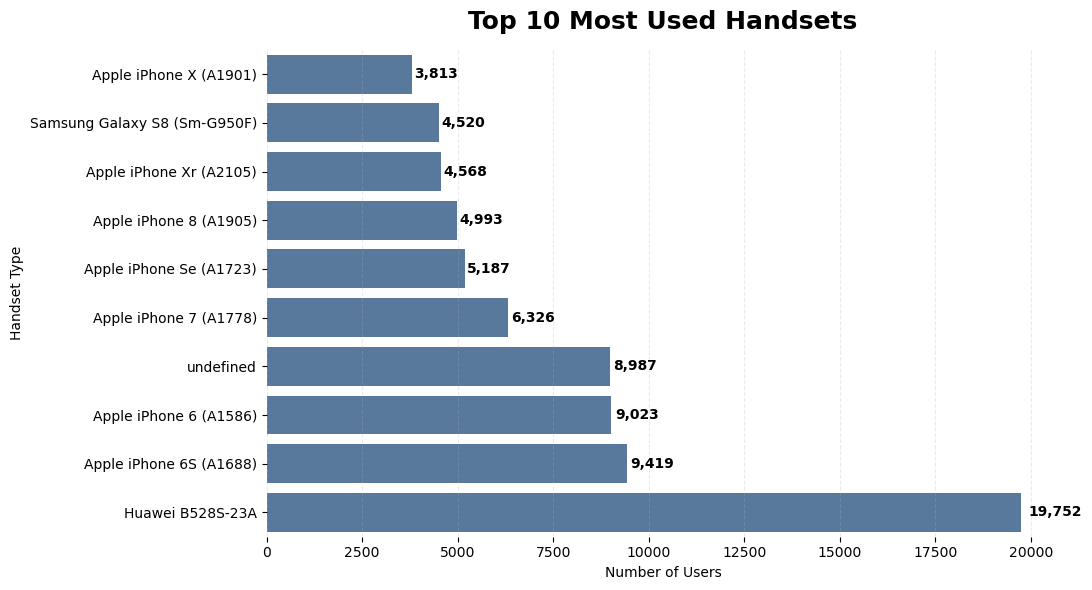

In [22]:
top_10_handsets = (
    df["Handset Type"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=top_10_handsets.values,
    y=top_10_handsets.index,
    color="#4C78A8"
)

for i, value in enumerate(top_10_handsets.values):
    ax.text(
        value + value * 0.01,
        i,
        f"{value:,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 10 Most Used Handsets",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Users")
plt.ylabel("Handset Type")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### Insights
+ The analysis shows that handset usage is concentrated among a small number of models. The most frequently used handset is Huawei B528S-23A with 19752 users, followed by Apple iPhone 6S (A1688) with 9419 users. This indicates that these models represent an important part of the customer device base and can be considered when optimizing device compatibility and marketing campaigns.

## Top Manufacturers

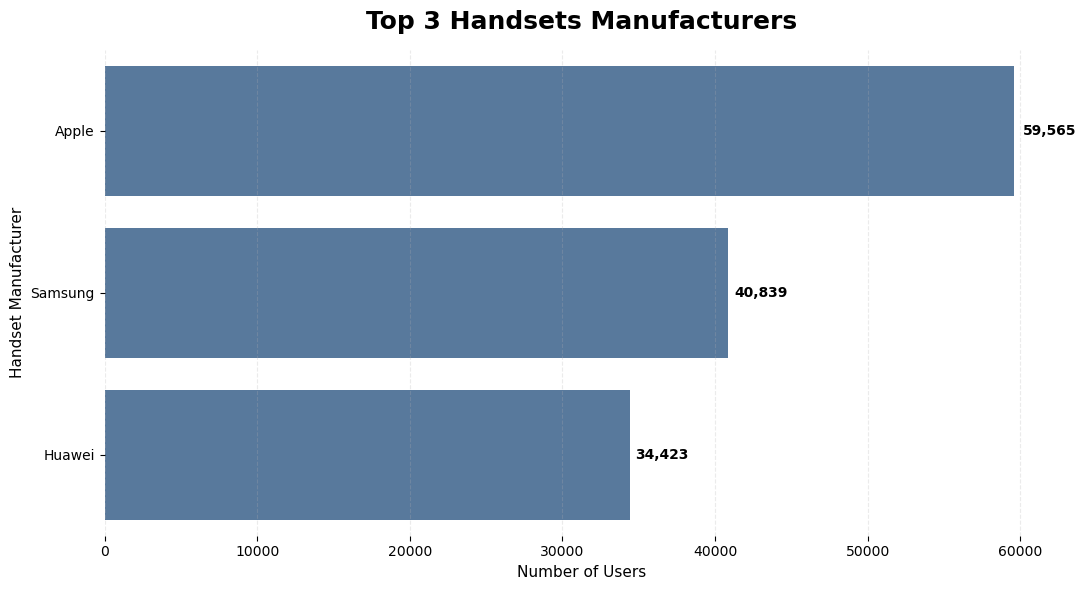

In [23]:
top_manufacturers = (
    df["Handset Manufacturer"]
    .value_counts()
    .head(3)
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=top_manufacturers.values,
    y=top_manufacturers.index,
    color="#4C78A8"
)

# Value labels
for i, value in enumerate(top_manufacturers.values):
    ax.text(
        value + value * 0.01,
        i,
        f"{value:,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 3 Handsets Manufacturers",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Users", fontsize=11)
plt.ylabel("Handset Manufacturer", fontsize=11)

sns.despine(left=True, bottom=True)
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Insights
+ The analysis shows that Apple is the number one leading headset manufacturer with 59,565 number of users, followed by Samsung (40,839) and Huawei (34,423). Therefore, the three leading handset manufacturers account for a substantial share of the observed handset usage. This indicates that network testing, device compatibility, and customer campaigns can initially focus on the most widely represented manufacturers.

## Top 5 Handsets for Each Top 3 Manufacturer

In [24]:
top_3_manufacturers = top_manufacturers.index

for manufacturer in top_3_manufacturers:

    temp = df[df["Handset Manufacturer"] == manufacturer]

    print(f"\nTop 5 handsets for {manufacturer}")

    print(
        temp["Handset Type"]
        .value_counts()
        .head(5)
    )


Top 5 handsets for Apple
Handset Type
Apple iPhone 6S (A1688)    9419
Apple iPhone 6 (A1586)     9023
Apple iPhone 7 (A1778)     6326
Apple iPhone Se (A1723)    5187
Apple iPhone 8 (A1905)     4993
Name: count, dtype: int64

Top 5 handsets for Samsung
Handset Type
Samsung Galaxy S8 (Sm-G950F)    4520
Samsung Galaxy A5 Sm-A520F      3724
Samsung Galaxy J5 (Sm-J530)     3696
Samsung Galaxy J3 (Sm-J330)     3484
Samsung Galaxy S7 (Sm-G930X)    3199
Name: count, dtype: int64

Top 5 handsets for Huawei
Handset Type
Huawei B528S-23A                  19752
Huawei E5180                       2079
Huawei P20 Lite Huawei Nova 3E     2021
Huawei P20                         1480
Huawei Y6 2018                      997
Name: count, dtype: int64


### Insight
+ Apple: The Apple iPhone 6S (A1688) is the most frequently observed Apple handset with 9,419 records, followed by the iPhone 6 with 9,023. The iPhone 7, iPhone SE, and iPhone 8 are also among the top Apple devices.
+ Samsung: The Samsung Galaxy S8 (SM-G950F) is the most frequently observed Samsung handset with 4,520 records. It is followed by the Galaxy A5, J5, J3, and S7.
+ Huawei: The Huawei B528S-23A is exceptionally dominant, with 19,752 records, far exceeding the other Huawei models. The Huawei E5180 is a distant second with 2,079 records.
+ Different handset patterns are visible across manufacturers. Apple and Samsung have usage distributed across several smartphone models, whereas Huawei's observations are heavily concentrated in the B528S-23A.
+ The high count of Huawei B528S-23A suggests that this particular device contributed a substantial number of xDR records in the dataset. However, record count should not automatically be interpreted as the number of unique customers, because a customer can generate multiple xDR/session records.

### Marketing implication: 
+ The company can prioritize commonly observed handset models when planning device-specific services, compatibility testing, promotions, and customer engagement initiatives. The particularly high number of Huawei B528S-23A observations may warrant further investigation to understand whether it represents a specific customer segment, device type, or usage pattern.

### Create Total Traffic

In [25]:
df["Total Traffic"] = (
    df["Total DL (Bytes)"] +
    df["Total UL (Bytes)"]
)

+ Total Traffic was derived by combining total download and upload traffic to obtain a single measure of the overall data consumption of each user. This metric is used in subsequent user-level analysis and decile analysis.

### Application Totals

In [26]:
df["Social Media Total"] = (
    df["Social Media DL (Bytes)"] +
    df["Social Media UL (Bytes)"]
)

df["Google Total"] = (
    df["Google DL (Bytes)"] +
    df["Google UL (Bytes)"]
)

df["Email Total"] = (
    df["Email DL (Bytes)"] +
    df["Email UL (Bytes)"]
)

df["YouTube Total"] = (
    df["Youtube DL (Bytes)"] +
    df["Youtube UL (Bytes)"]
)

df["Netflix Total"] = (
    df["Netflix DL (Bytes)"] +
    df["Netflix UL (Bytes)"]
)

df["Gaming Total"] = (
    df["Gaming DL (Bytes)"] +
    df["Gaming UL (Bytes)"]
)

df["Other Total"] = (
    df["Other DL (Bytes)"] +
    df["Other UL (Bytes)"]
)

+ For each application, download and upload traffic were combined to calculate total application-level data usage. This provides a unified measure of the amount of data consumed by users across different applications.

In [27]:
user_df = df.groupby("MSISDN/Number").agg(
    
    Sessions=("Bearer Id", "count"),
    
    Total_Duration=("Dur. (ms)", "sum"),
    
    Total_DL=("Total DL (Bytes)", "sum"),
    
    Total_UL=("Total UL (Bytes)", "sum"),
    
    Social_Media=("Social Media Total", "sum"),
    
    Google=("Google Total", "sum"),
    
    Email=("Email Total", "sum"),
    
    YouTube=("YouTube Total", "sum"),
    
    Netflix=("Netflix Total", "sum"),
    
    Gaming=("Gaming Total", "sum"),
    
    Other=("Other Total", "sum")
    
).reset_index()

+ The session-level records were aggregated by MSISDN/Number to create a customer-level dataset. For each customer, the number of sessions, total session duration, total download traffic, total upload traffic, and application-level data usage were calculated. This aggregation enables analysis of individual customer behavior rather than analyzing each xDR session independently.

In [28]:
user_df["Total Traffic"] = (
    user_df["Total_DL"] +
    user_df["Total_UL"]
)

+ Total Traffic was created by combining total download and upload traffic to measure the overall data usage of each customer.

### Convert Units

Data volume originally recorded in bytes was converted to gigabytes to make traffic values easier to interpret and present in visualizations and reports. Similarly, session duration was converted from milliseconds to hours for improved readability.

#### Convert Traffic to GB

In [29]:
user_df["Total Traffic GB"] = (
    user_df["Total Traffic"] / (1024 ** 3)
)

#### Convert Duration from Milliseconds to Hours

In [30]:
user_df["Total Duration Hours"] = (
    user_df["Total_Duration"] / (1000 * 60 * 60)
)

#### Converts Application to GB

In [31]:
app_columns = [
    "Social_Media",
    "Google",
    "Email",
    "YouTube",
    "Netflix",
    "Gaming",
    "Other"
]

for col in app_columns:
    user_df[col + "_GB"] = (
        user_df[col] / (1024 ** 3)
    )

## Basic Statistics

In [32]:
numeric_user_df = user_df.select_dtypes(include=np.number)

basic_stats = numeric_user_df.describe().T

summary_stats = pd.DataFrame({
    "Mean": numeric_user_df.mean(),
    "Median": numeric_user_df.median(),
    "Std": numeric_user_df.std(),
    "Min": numeric_user_df.min(),
    "Max": numeric_user_df.max()
})

summary_stats

,Mean,Median,Std,Min,Max
Sessions,1.403745e+00,1.000000e+00,3.352062e+00,1.000000e+00,1.065000e+03
Total_Duration,1.468438e+05,1.027410e+05,2.892198e+05,7.142000e+03,7.244640e+07
Total_DL,6.382035e+08,5.703713e+08,1.558474e+09,8.827082e+06,4.869236e+11
Total_UL,5.772370e+07,4.679434e+07,1.400375e+08,2.866892e+06,4.432530e+10
Social_Media,2.566397e+06,2.303811e+06,6.319700e+06,1.563000e+03,1.971989e+09
Google,1.095945e+07,9.586186e+06,2.628254e+07,4.033000e+04,8.240770e+09
Email,3.171204e+06,2.799854e+06,7.654726e+06,1.817600e+04,2.397621e+09
YouTube,3.178568e+07,2.680040e+07,7.728729e+07,7.890300e+04,2.431808e+10
Netflix,3.176480e+07,2.671955e+07,7.702965e+07,1.845690e+05,2.423094e+10
Gaming,6.040780e+08,5.423501e+08,1.478448e+09,3.063580e+05,4.610477e+11


 + The statistical analysis shows that mean is generally larger than median. Therefore, the difference between the mean and median indicates a right-skewed distribution, suggesting that a relatively small number of users have substantially higher usage than the typical customer.

In [33]:
dispersion = pd.DataFrame({
    "Range": numeric_user_df.max() - numeric_user_df.min(),
    "Variance": numeric_user_df.var(),
    "Standard Deviation": numeric_user_df.std(),
    "IQR": (
        numeric_user_df.quantile(0.75)
        - numeric_user_df.quantile(0.25)
    )
})

dispersion

,Range,Variance,Standard Deviation,IQR
Sessions,1.064000e+03,1.123632e+01,3.352062e+00,1.000000e+00
Total_Duration,7.243925e+07,8.364809e+10,2.892198e+05,1.014900e+05
Total_DL,4.869148e+11,2.428841e+18,1.558474e+09,4.925399e+08
Total_UL,4.432244e+10,1.961050e+16,1.400375e+08,2.933823e+07
Social_Media,1.971988e+09,3.993860e+13,6.319700e+06,2.096215e+06
Google,8.240729e+09,6.907719e+14,2.628254e+07,7.272272e+06
Email,2.397603e+09,5.859482e+13,7.654726e+06,2.172721e+06
YouTube,2.431800e+10,5.973325e+15,7.728729e+07,1.929684e+07
Netflix,2.423076e+10,5.933567e+15,7.702965e+07,1.942115e+07
Gaming,4.610474e+11,2.185809e+18,1.478448e+09,4.892449e+08


### Insights
+ The descriptive analysis shows substantial variability in network usage, particularly for Total Traffic, Total Download, Gaming, and Other traffic. The large differences between the range and IQR suggest the presence of extreme observations and potentially right-skewed distributions.
+ Sessions has a relatively small range of 1,064 and an IQR of 1. The very small IQR compared with the range indicates that most observations have a similar number of sessions, while a few observations may have unusually high session counts.
+ Total_DL has an extremely large range (~ 4.87 × 10¹¹) and standard deviation (~ 1.56 × 10⁹). Total_UL also shows substantial variability, although it is considerably smaller than Total_DL. This indicates that download traffic is much more variable and generally contributes more traffic than upload traffic.
+ Gaming has one of the largest ranges and standard deviations followed by Other. YouTube and Netflix have substantial variation, but considerably less than Gaming and Other, whereas Email and Social Media show comparatively lower variability. This suggests that users have very different application-usage patterns, with some users consuming substantially more data through particular applications.
+ Total Traffic has a range of approximately 5.31 × 10¹¹ and standard deviation of approximately 1.70 × 10⁹. Its high variability indicates that overall data consumption differs significantly between users.
+ Range is extremely large compared with IQR. This suggests that the extreme observations are far away from the central 50% of the data, indicating potential outliers and right-skewed distributions.

### Session Frequency

In [34]:
# Modern plotting style
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

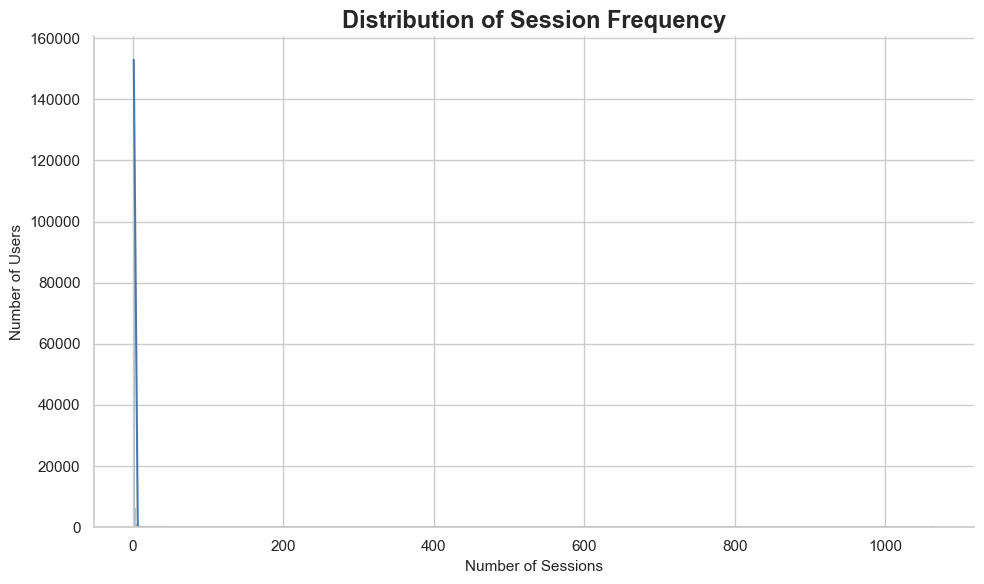

In [35]:
plt.figure(figsize=(10, 6))

sns.histplot(
    user_df["Sessions"],
    kde=True,
    color="#4C78A8"
)

plt.title(
    "Distribution of Session Frequency",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Number of Sessions")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

### Session Duration

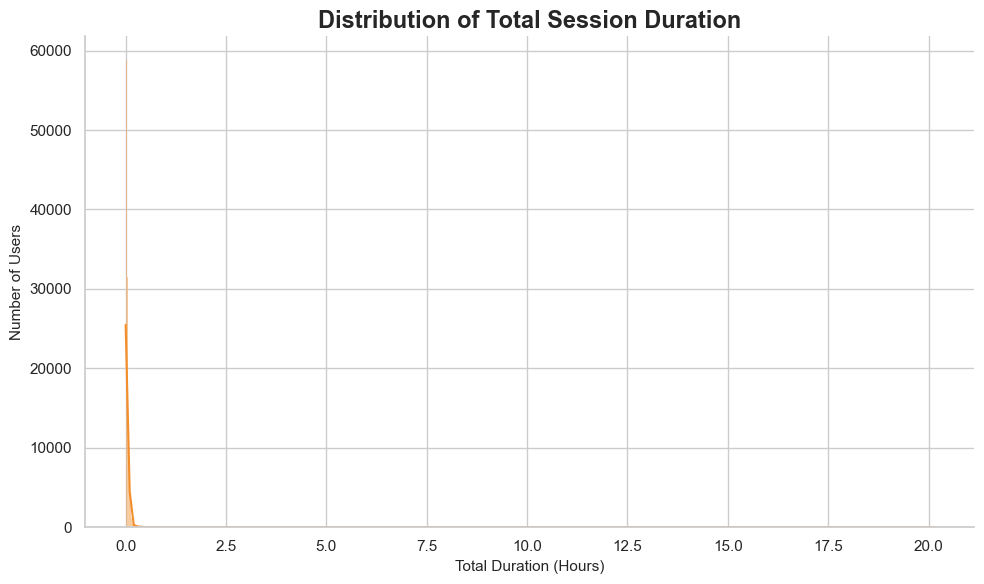

In [36]:
plt.figure(figsize=(10, 6))

sns.histplot(
    user_df["Total Duration Hours"],
    kde=True,
    color="#F28E2B"
)

plt.title(
    "Distribution of Total Session Duration",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Total Duration (Hours)")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

### Total Traffic 

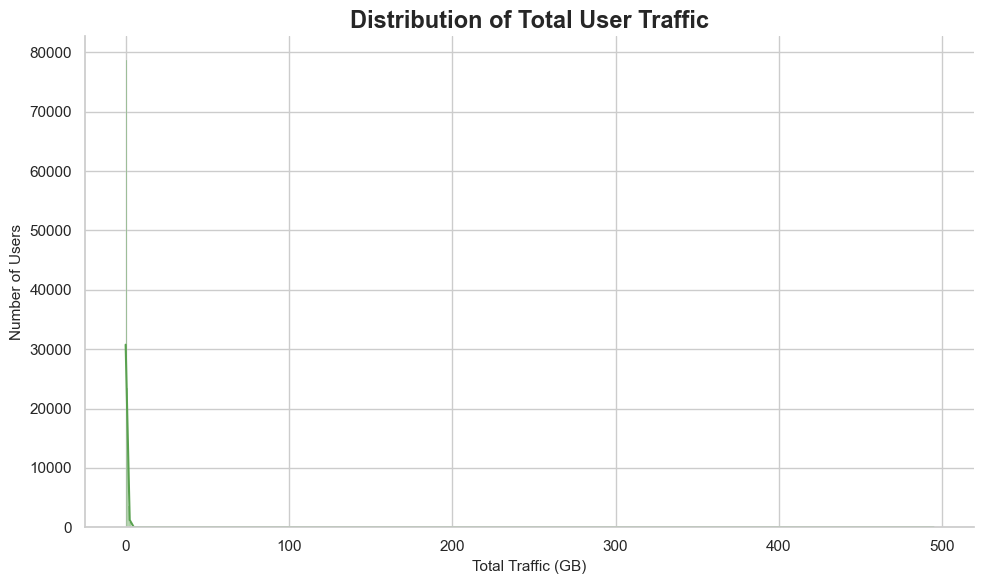

In [37]:
plt.figure(figsize=(10, 6))

sns.histplot(
    user_df["Total Traffic GB"],
    kde=True,
    color="#59A14F"
)

plt.title(
    "Distribution of Total User Traffic",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Total Traffic (GB)")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

### Boxplots

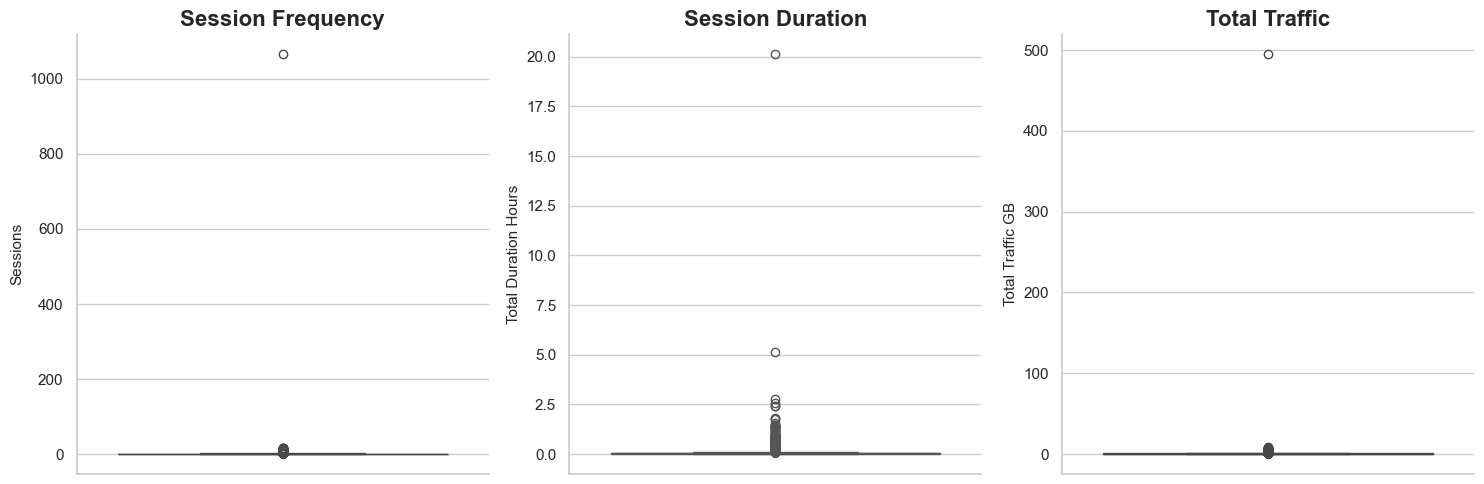

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(
    y=user_df["Sessions"],
    ax=axes[0],
    color="#4C78A8"
)

axes[0].set_title("Session Frequency")

sns.boxplot(
    y=user_df["Total Duration Hours"],
    ax=axes[1],
    color="#F28E2B"
)

axes[1].set_title("Session Duration")

sns.boxplot(
    y=user_df["Total Traffic GB"],
    ax=axes[2],
    color="#59A14F"
)

axes[2].set_title("Total Traffic")

plt.tight_layout()
plt.show()

### Application Usage Analysis

In [39]:
app_gb = user_df[
    [
        "Social_Media_GB",
        "Google_GB",
        "Email_GB",
        "YouTube_GB",
        "Netflix_GB",
        "Gaming_GB",
        "Other_GB"
    ]
].sum().sort_values(ascending=False)

app_gb

Gaming_GB          60116.839694
Other_GB           59981.645590
YouTube_GB          3163.257982
Netflix_GB          3161.179815
Google_GB           1090.666449
Email_GB             315.592947
Social_Media_GB      255.403604
dtype: float64

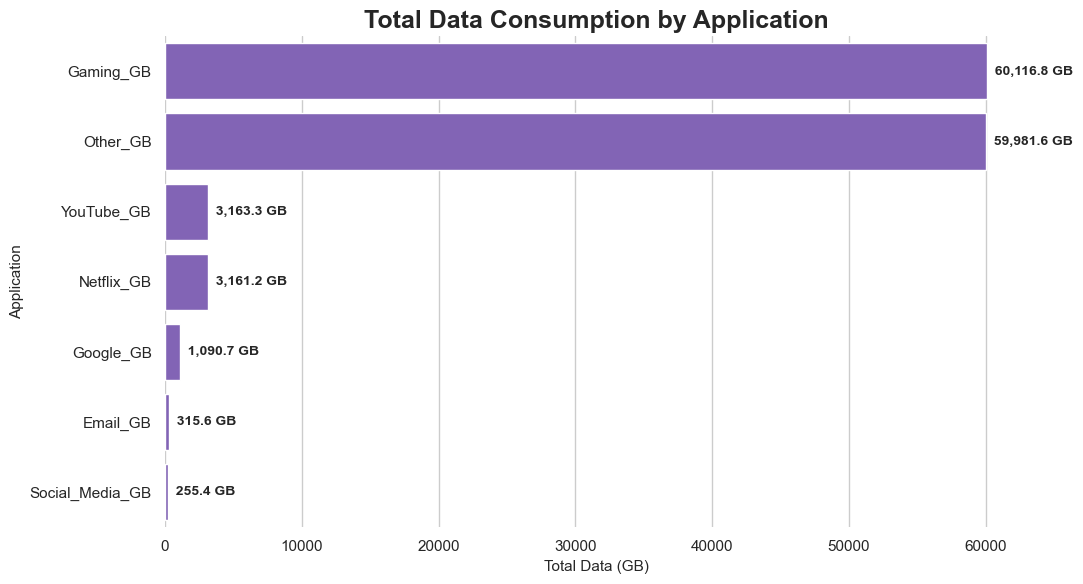

In [40]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=app_gb.values,
    y=app_gb.index,
    color="#7E57C2"
)

for i, value in enumerate(app_gb.values):
    ax.text(
        value,
        i,
        f"  {value:,.1f} GB",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Total Data Consumption by Application",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Total Data (GB)")
plt.ylabel("Application")

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### Insight 
+ Gaming has the highest total data consumption at approximately 60,116.84 GB, making it the largest contributor to overall application data usage.
+ Other applications are very close at 59,981.65 GB, indicating that miscellaneous activities also account for a substantial amount of data consumption.
+ YouTube (3,163.26 GB) and Netflix (3,161.18 GB) have almost identical total usage, showing that video-streaming applications contribute similarly to overall data consumption.
+ Google (1,090.67 GB) has considerably lower usage than YouTube and Netflix.
+ Email (315.59 GB) and Social Media (255.40 GB) have the lowest total data consumption among the listed applications.
+ Overall, the analysis indicates that gaming and miscellaneous activities are the major contributors to total application-level data consumption in the dataset.

### Applications vs Total Traffic

#### Correlation 

In [41]:
app_vs_total = user_df[
    app_gb.index.tolist() + ["Total Traffic GB"]
].corr()["Total Traffic GB"].drop("Total Traffic GB")

app_vs_total.sort_values(ascending=False)

Gaming_GB          0.999625
YouTube_GB         0.976361
Netflix_GB         0.976299
Google_GB          0.973540
Email_GB           0.971731
Social_Media_GB    0.967039
Other_GB           0.965562
Name: Total Traffic GB, dtype: float64

+ The correlation analysis reveals extremely strong positive relationships between Total Traffic GB and all application-level usage variables, with correlation coefficients ranging from 0.966 to 1.000. This indicates that users with higher application-level data consumption generally have higher overall traffic. The exceptionally high correlations may also be due to the fact that application traffic contributes directly to the calculation of total traffic.

#### Scatterplots

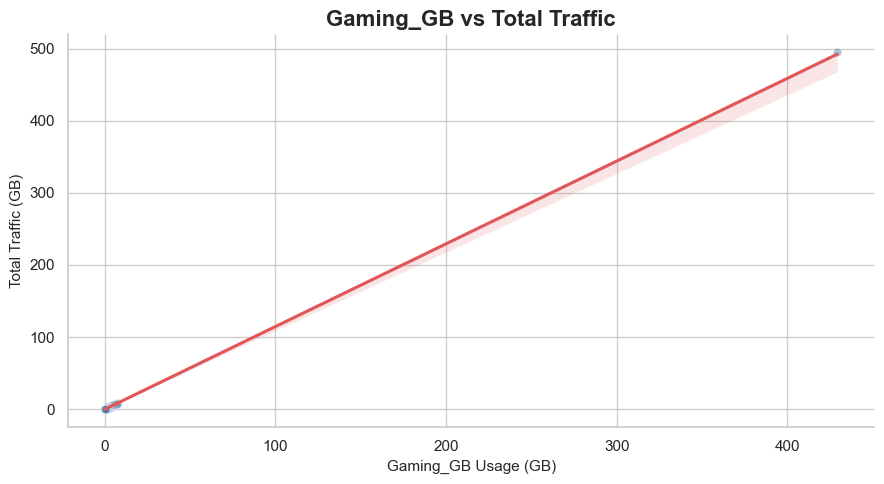

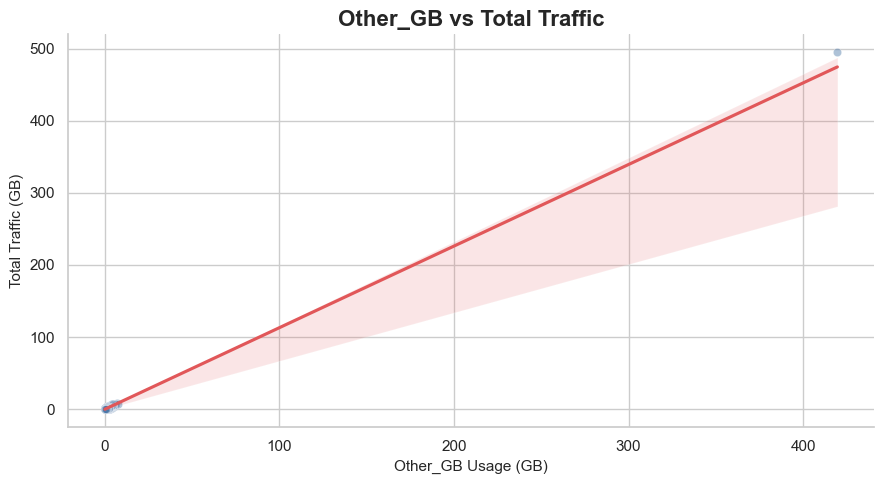

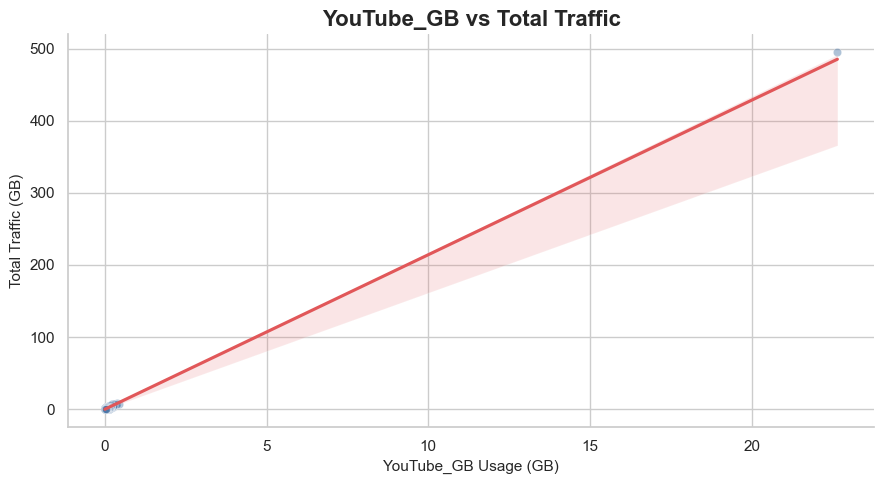

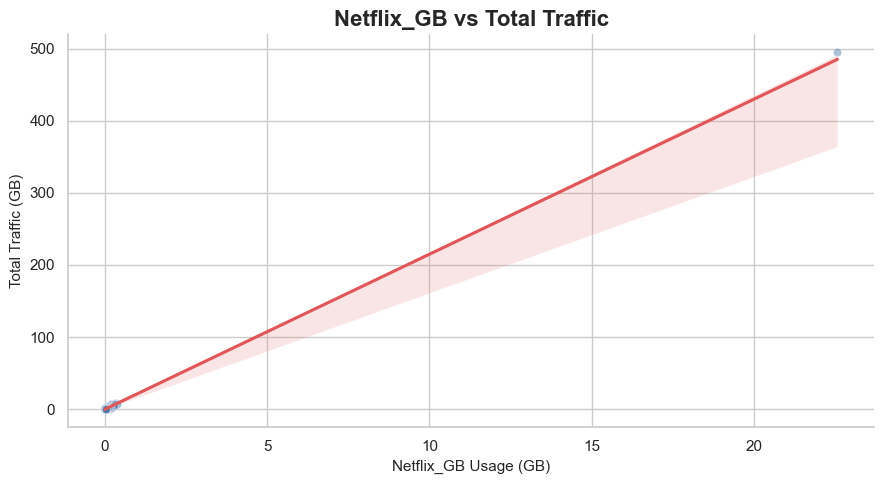

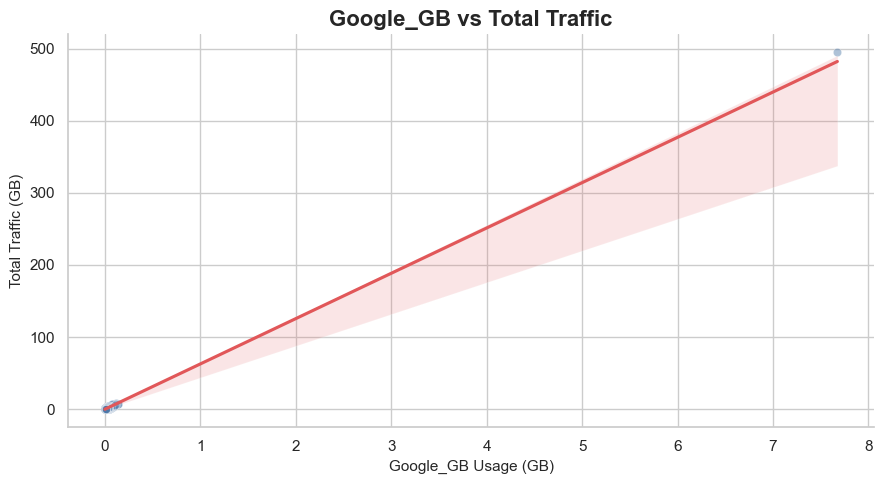

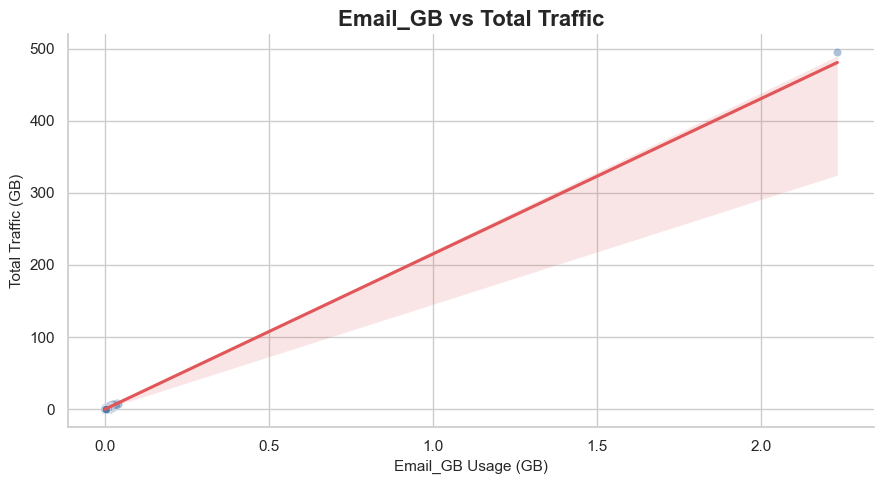

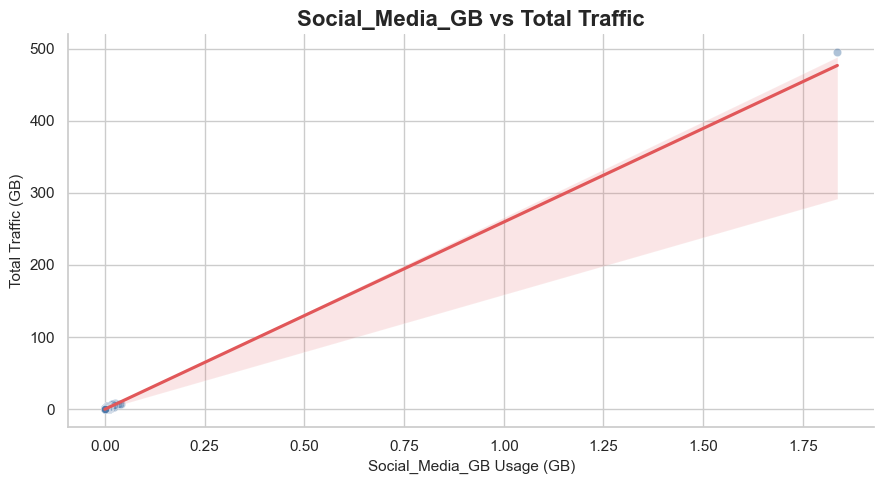

In [42]:
for app in app_gb.index:
    
    plt.figure(figsize=(9, 5))
    
    sns.scatterplot(
        data=user_df,
        x=app,
        y="Total Traffic GB",
        alpha=0.45,
        color="#4C78A8"
    )
    
    sns.regplot(
        data=user_df,
        x=app,
        y="Total Traffic GB",
        scatter=False,
        color="#E15759"
    )
    
    plt.title(
        f"{app} vs Total Traffic",
        fontsize=16,
        fontweight="bold"
    )
    
    plt.xlabel(f"{app} Usage (GB)")
    plt.ylabel("Total Traffic (GB)")
    
    plt.tight_layout()
    plt.show()

#### Insight
+ The scatterplots show a clear and strong positive linear relationship between application-level data usage and Total Traffic GB. As the data consumed by individual applications increases, overall traffic also increases.
+ Gaming shows the strongest and most linear relationship, followed by YouTube and Netflix. The close clustering of points around the upward trend confirms the very high correlations observed in the correlation analysis.
+ The application variables do not show a downward trend with Total Traffic.

### Decile Analysis

In [43]:
user_df["Duration Decile"] = pd.qcut(
    user_df["Total Duration Hours"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

In [44]:
user_df["Duration Decile"].value_counts().sort_index()

Duration Decile
1     10688
2     10684
3     10744
4     12082
5      9231
6     10685
7     10686
8     10686
9     10685
10    10686
Name: count, dtype: int64

In [45]:
decile_analysis = (
    user_df
    .groupby("Duration Decile")
    .agg(
        Total_Duration_Hours=("Total Duration Hours", "sum"),
        Total_Traffic_GB=("Total Traffic GB", "sum"),
        Number_of_Users=("MSISDN/Number", "count")
    )
    .reset_index()
)

decile_analysis

,Duration Decile,Total_Duration_Hours,Total_Traffic_GB,Number_of_Users
0,1,59.593971,5065.721127,10688
1,2,119.390780,5689.831830,10684
2,3,212.330089,6087.498457,10744
3,4,289.863251,5619.824693,12082
4,5,241.726780,4790.892542,9231
5,6,348.546254,5984.493776,10685
6,7,438.669553,5729.941504,10686
7,8,519.277573,7285.023306,10686
8,9,690.762802,8667.128382,10685
9,10,1438.528960,14337.164014,10686


#### Top Deciles

In [46]:
top_5_deciles = decile_analysis[
    decile_analysis["Duration Decile"] >= 6
]

top_5_deciles

,Duration Decile,Total_Duration_Hours,Total_Traffic_GB,Number_of_Users
5,6,348.546254,5984.493776,10685
6,7,438.669553,5729.941504,10686
7,8,519.277573,7285.023306,10686
8,9,690.762802,8667.128382,10685
9,10,1438.528960,14337.164014,10686


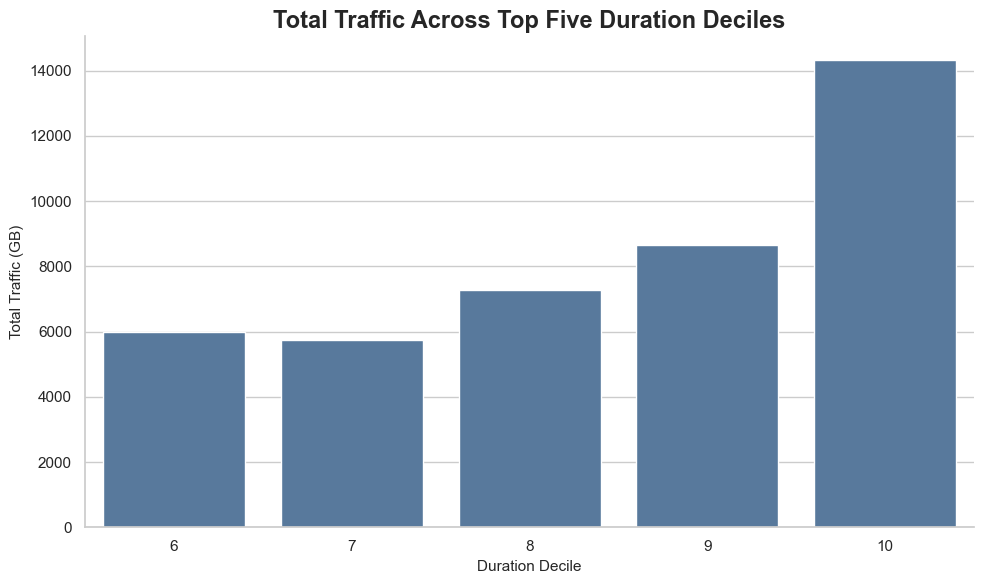

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_5_deciles,
    x="Duration Decile",
    y="Total_Traffic_GB",
    color="#4C78A8"
)

plt.title(
    "Total Traffic Across Top Five Duration Deciles",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Duration Decile")
plt.ylabel("Total Traffic (GB)")

plt.tight_layout()
plt.show()

### Insight
+ Traffic generally increases with session duration. From duration decile 6 to 10, total traffic rises from roughly 5,900 GB to 14,300 GB. This suggests that longer-duration users tend to generate substantially more data traffic.
+ The highest-duration group is particularly significant. Decile 10 accounts for approximately 14,300 GB, considerably higher than the other groups. It is about 2.4× the traffic of decile 6.
+ There is a noticeable jump after decile 7. The increase becomes particularly pronounced in the highest duration decile.
+ Long-duration users may be important for network capacity planning.
Since the highest-duration users generate disproportionately large amounts of traffic, they could have a significant impact on overall network resource consumption.
+ Overall, the analysis shows a generally positive relationship between session duration and total traffic consumption. Users in the higher duration deciles tend to generate substantially more traffic, with the highest duration decile producing approximately 14,300 GB compared with around 5,900 GB in decile 6. The particularly large increase in traffic for decile 10 suggests that the longest-duration users contribute disproportionately to overall network traffic. This pattern may be useful for understanding network resource utilization and identifying high-traffic user segments.

In [48]:
app_features = [
    "Social_Media_GB",
    "Google_GB",
    "Email_GB",
    "YouTube_GB",
    "Netflix_GB",
    "Gaming_GB",
    "Other_GB"
]

corr_matrix = user_df[app_features].corr()

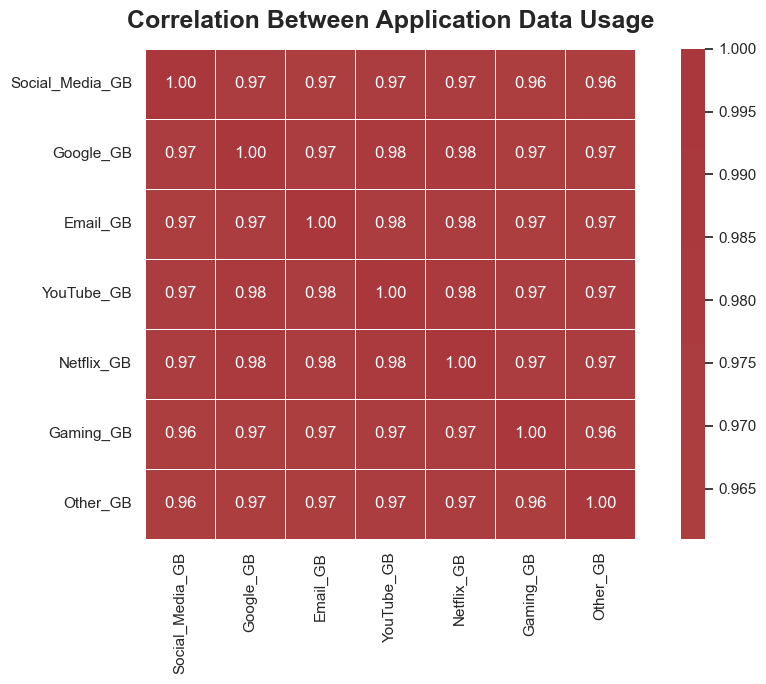

In [49]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Between Application Data Usage",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

### Insight
+ The correlation analysis reveals very strong positive relationships among all data-usage variables, with correlation coefficients ranging from 0.96 to 0.98. This indicates substantial multicollinearity and suggests that the different categories of internet usage are driven by a common underlying pattern of overall data consumption.

## PCA

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_app = user_df[app_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_app)

In [51]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [52]:
explained_variance = pd.DataFrame({
    "Component": [
        f"PC{i+1}"
        for i in range(len(pca.explained_variance_ratio_))
    ],
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative Variance": (
        pca.explained_variance_ratio_.cumsum()
    )
})

explained_variance

,Component,Explained Variance,Cumulative Variance
0,PC1,0.974633,0.974633
1,PC2,0.005589,0.980221
2,PC3,0.005360,0.985581
3,PC4,0.004613,0.990195
4,PC5,0.003720,0.993915
5,PC6,0.003241,0.997156
6,PC7,0.002844,1.000000


### PCA Variance Plot

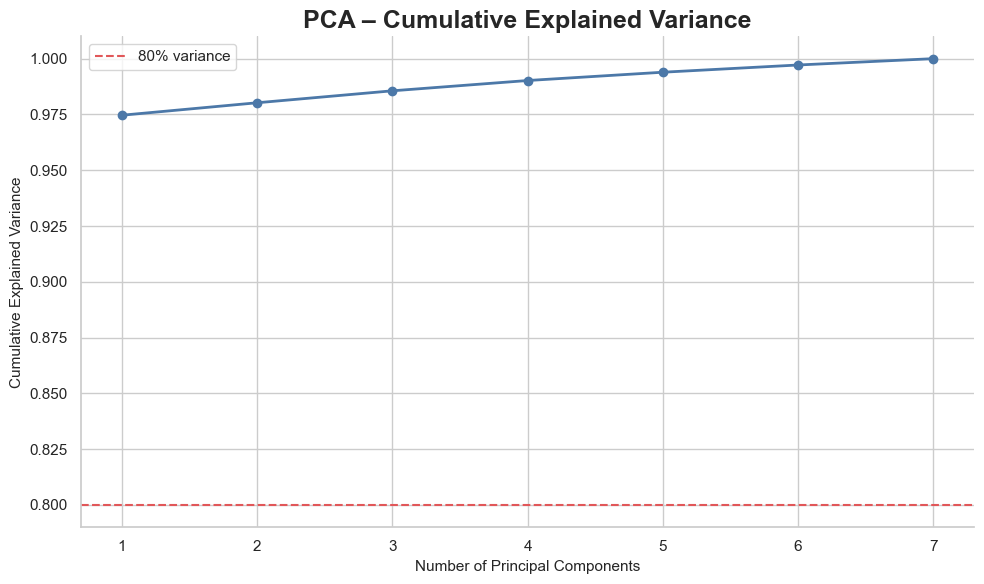

In [53]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_.cumsum(),
    marker="o",
    linewidth=2,
    color="#4C78A8"
)

plt.axhline(
    0.80,
    linestyle="--",
    color="#E15759",
    label="80% variance"
)

plt.title(
    "PCA – Cumulative Explained Variance",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.legend()

plt.tight_layout()
plt.show()

#### Insight
+ The first principal component already explains ~97.5% of the variance. This means most of the information in the original dataset is captured by just one principal component.
+ The 80% variance threshold is exceeded immediately. The dashed red line represents the 80% target. PC1 is already well above it (~0.975), so only 1 component is needed to retain at least 80% of the variance. Additional components provide relatively small gains.
+ After the first component, each additional component contributes only a small amount of new information. There is strong redundancy/correlation in the original features. Such a high variance captured by PC1 suggests that the original variables likely contain substantial shared information and may be highly correlated.



In [54]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[
        f"PC{i+1}"
        for i in range(len(app_features))
    ],
    index=app_features
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Social_Media_GB,0.376913,-0.180509,0.751065,-0.499927,0.065794,0.083660,-0.000496
Google_GB,0.378643,-0.026968,0.014599,0.330333,-0.638729,0.580947,-0.033087
Email_GB,0.378277,-0.025215,0.051077,0.509884,0.725652,0.259040,0.002512
YouTube_GB,0.379306,-0.014382,0.012804,0.203668,-0.164935,-0.503766,0.730269
Netflix_GB,0.379263,-0.031144,0.019646,0.213217,-0.144739,-0.568356,-0.682177
Gaming_GB,0.376762,-0.540782,-0.613721,-0.416880,0.091540,0.082340,-0.001842
Other_GB,0.376575,0.820019,-0.236382,-0.346757,0.067769,0.069366,-0.015435


#### Insight
The PCA results indicate that PC1 represents a common application usage pattern, as all seven applications contribute similarly and positively. The remaining components capture contrasts between specific applications, such as Other and Gaming, Social Media and Gaming, and YouTube and Netflix. This suggests that although application usage shares a common overall pattern, customers also demonstrate different preferences across individual applications.


### PCA Interpretation
+ High variance explained by PC1: The first principal component (PC1) explains approximately 97.5% of the total variance. All seven applications have similar positive loadings, indicating a common pattern of overall application usage among customers.
+ Remaining components contribute little variance: PC2 to PC7 collectively explain only around 2.5% of the variance. Although they capture differences between individual applications, their contribution to the overall data variation is relatively small.
+ Application usage patterns: The loadings show contrasts such as Other versus Gaming in PC2, Social Media versus Gaming in PC3, and YouTube versus Netflix in PC7. These components reflect differences in application preferences, but explain only small amounts of total variance.
+ Dimensionality reduction: The cumulative explained variance exceeds the 80% threshold with just one principal component, reaching approximately 97.5%. Therefore, PC1 alone can represent most of the variation in application usage, reducing the seven original features to one component with minimal information loss.

# User Engagement Analysis

## Introduction
User engagement analysis aims to understand how actively customers use the mobile network and its available applications. In this analysis, customer engagement is evaluated based on their activity across data sessions. Three key engagement metrics are considered: session frequency, session duration, and total session traffic (download and upload data).

The session-level data is aggregated at the customer level using the MSISDN/Number to calculate these engagement metrics. Customers are then analyzed based on their usage patterns and grouped into different engagement segments using K-Means clustering. Application-level usage is also analyzed to identify the most engaged users and the applications generating the highest data traffic.

## Objective
The objective of this analysis is to identify different levels of customer engagement and understand how network and application usage are distributed across these customer segments. These findings can help identify areas where network resources and customer engagement initiatives may be focused.

In [55]:
user_df.head()

,MSISDN/Number,Sessions,Total_Duration,Total_DL,Total_UL,Social_Media,Google,Email,YouTube,Netflix,...,Total Traffic GB,Total Duration Hours,Social_Media_GB,Google_GB,Email_GB,YouTube_GB,Netflix_GB,Gaming_GB,Other_GB,Duration Decile
0,33601001722.0,1,116720.0,8.426375e+08,36053108.0,2232135.0,4389005.0,1331362.0,21624548.0,27180981.0,...,0.818344,0.032422,0.002079,0.004088,0.001240,0.020139,0.025314,0.756661,0.360022,6
1,33601001754.0,1,181230.0,1.207552e+08,36104459.0,2660565.0,5334863.0,3307781.0,12432223.0,11221763.0,...,0.146087,0.050342,0.002478,0.004968,0.003081,0.011578,0.010451,0.111526,0.262363,8
2,33601002511.0,1,134969.0,5.566597e+08,39306820.0,3195623.0,3443126.0,3205380.0,21333570.0,19353900.0,...,0.555037,0.037491,0.002976,0.003207,0.002985,0.019868,0.018025,0.501822,0.467239,7
3,33601007832.0,1,49878.0,4.019932e+08,20327526.0,280294.0,9678493.0,2284670.0,6977321.0,1942092.0,...,0.393317,0.013855,0.000261,0.009014,0.002128,0.006498,0.001809,0.364265,0.032857,2
4,33601008617.0,2,37104.0,1.363130e+09,94280527.0,2912542.0,18499616.0,3305469.0,41533002.0,49201724.0,...,1.357320,0.010307,0.002713,0.017229,0.003078,0.038681,0.045823,1.224501,0.749533,2


In [56]:
print(user_df.shape)
print(user_df.columns.tolist())

(106857, 23)
['MSISDN/Number', 'Sessions', 'Total_Duration', 'Total_DL', 'Total_UL', 'Social_Media', 'Google', 'Email', 'YouTube', 'Netflix', 'Gaming', 'Other', 'Total Traffic', 'Total Traffic GB', 'Total Duration Hours', 'Social_Media_GB', 'Google_GB', 'Email_GB', 'YouTube_GB', 'Netflix_GB', 'Gaming_GB', 'Other_GB', 'Duration Decile']


+ The customer-level dataset generated during Task 1 is used as the starting point for User Engagement Analysis. Each row represents a customer, with aggregated measures of session activity, duration, total traffic, and application usage.

## Create Engagement Metrics

In [57]:
engagement_df = user_df[
    ["MSISDN/Number", "Sessions", "Total Duration Hours", "Total Traffic GB"]
].copy()

In [58]:
engagement_df.rename(columns={
    "Sessions": "Session_Frequency",
    "Total Duration Hours": "Session_Duration",
    "Total Traffic GB": "Total_Traffic"
}, inplace=True)

In [59]:
engagement_df.isnull().sum()

MSISDN/Number        0
Session_Frequency    0
Session_Duration     0
Total_Traffic        0
dtype: int64

In [60]:
engagement_metrics = [
    "Session_Frequency",
    "Session_Duration",
    "Total_Traffic"
]

engagement_df[engagement_metrics].describe()

,Session_Frequency,Session_Duration,Total_Traffic
count,106857.000000,106857.000000,106857.000000
mean,1.403745,0.040790,0.648133
std,3.352062,0.080339,1.579249
min,1.000000,0.001984,0.030966
25%,1.000000,0.019808,0.333928
50%,1.000000,0.028539,0.575486
75%,2.000000,0.048000,0.798549
max,1065.000000,20.123999,494.764135


### Insights
1. Session Frequency:
- The average session frequency is 1.40, while the median is only 1, meaning most users have around one session.
- The maximum value is 1065, which is extremely high compared with the 75th percentile of 2. This indicates a strong right-skew and the presence of extreme values/outliers.
-Most users have low session frequency, while a small number of users generate a very large number of sessions.

2. Session Duration:
- The average session duration is 0.0408, while the median is 0.0285. Since the mean is higher than the median, the distribution is also right-skewed.
- The maximum duration of 20.124 is much higher than the 75th percentile of 0.048, suggesting some sessions are unusually long. Most sessions therefore have relatively short durations.

3. Total Traffic:
- The average total traffic is 0.648 GB, while the median is 0.575 GB. The 75th percentile is 0.799 GB, so most users have traffic below approximately 0.8 GB.
- However, the maximum is 494.76 GB, which is extremely high compared with the median. This indicates a strongly right-skewed traffic distribution, with a small number of users consuming very large amounts of data.

Overall, session frequency, session duration, and total traffic are all highly right-skewed. Most users have relatively few sessions, short session durations, and moderate data consumption, while a small number of users show exceptionally high activity and traffic.

In [61]:
engagement_metrics = [
    "Session_Frequency",
    "Session_Duration",
    "Total_Traffic"
]

outlier_report = []

for col in engagement_metrics:
    
    Q1 = engagement_df[col].quantile(0.25)
    Q3 = engagement_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (
        (engagement_df[col] < lower_bound) |
        (engagement_df[col] > upper_bound)
    )
    
    outlier_count = outlier_mask.sum()
    outlier_percentage = (
        outlier_count / len(engagement_df) * 100
    )
    
    outlier_report.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": outlier_percentage
    })

outlier_report = pd.DataFrame(outlier_report)

outlier_report

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Session_Frequency,1.000000,2.000000,1.000000,-0.500000,3.500000,3252,3.043320
1,Session_Duration,0.019808,0.048000,0.028192,-0.022479,0.090287,8053,7.536240
2,Total_Traffic,0.333928,0.798549,0.464621,-0.363003,1.495481,5283,4.943991


 Customer-level outlier analysis was performed on session frequency, session duration, and total traffic using the IQR method before clustering. This additional check was used to identify extreme customer-level usage patterns that could disproportionately influence K-Means clustering.

#### Visualization

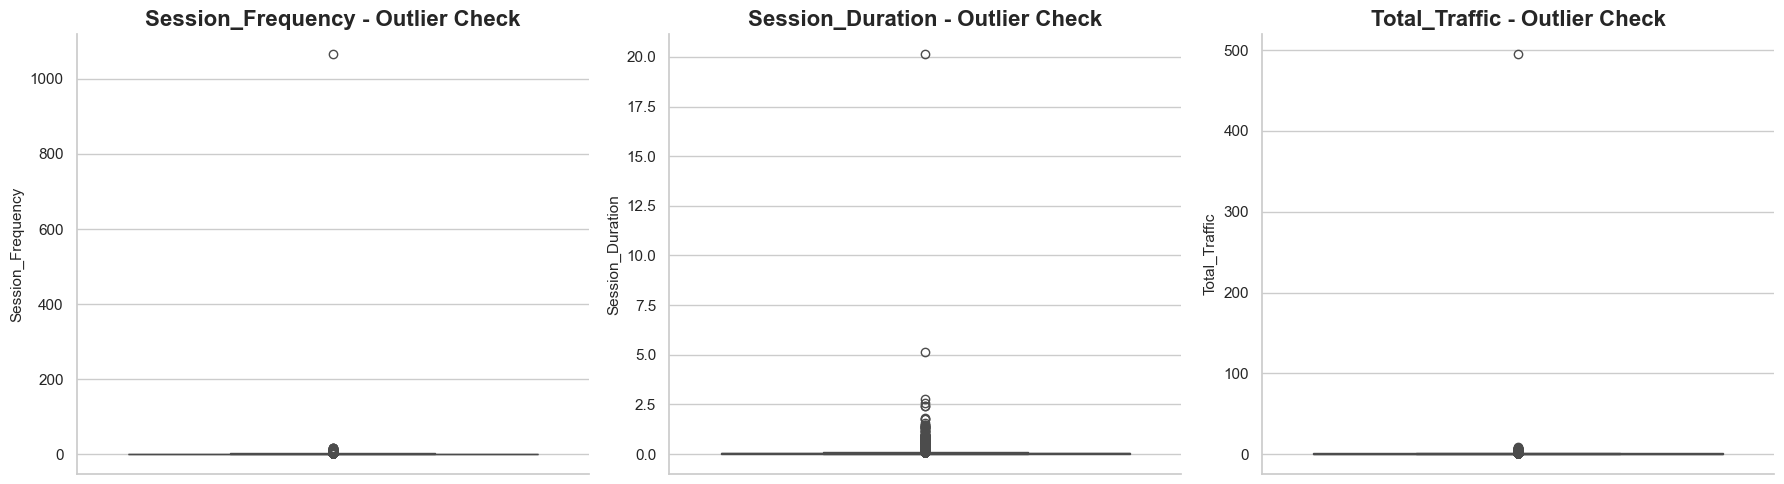

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, engagement_metrics):
    sns.boxplot(
        y=engagement_df[col],
        ax=ax
    )
    ax.set_title(f"{col} - Outlier Check")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

#### Outliers Treatment

In [63]:
engagement_clean = engagement_df.copy()

for col in engagement_metrics:
    
    # Convert column to float so decimal mean values can be assigned
    engagement_clean[col] = engagement_clean[col].astype(float)
    
    Q1 = engagement_clean[col].quantile(0.25)
    Q3 = engagement_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (
        (engagement_clean[col] < lower_bound) |
        (engagement_clean[col] > upper_bound)
    )
    
    mean_value = engagement_clean.loc[
        ~outlier_mask, col
    ].mean()
    
    engagement_clean.loc[
        outlier_mask, col
    ] = mean_value

In [64]:
for col in engagement_metrics:
    
    # Original bounds
    Q1 = engagement_df[col].quantile(0.25)
    Q3 = engagement_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Before treatment
    before_outliers = (
        (engagement_df[col] < lower_bound) |
        (engagement_df[col] > upper_bound)
    ).sum()
    
    # After treatment
    after_outliers = (
        (engagement_clean[col] < lower_bound) |
        (engagement_clean[col] > upper_bound)
    ).sum()
    
    print(
        f"{col}: "
        f"Before = {before_outliers}, "
        f"After = {after_outliers}"
    )

Session_Frequency: Before = 3252, After = 0
Session_Duration: Before = 8053, After = 0
Total_Traffic: Before = 5283, After = 0


#### Insights
+ Session Duration had the highest number of outliers, with 8,053 observations (7.54%), indicating greater variability in users' session lengths.
+ Total Traffic had 5,283 outliers (4.94%), suggesting that a smaller group of users generated unusually high or low traffic compared with the majority.
+ Session Frequency had the lowest outlier percentage, with 3,252 observations (3.04%), indicating relatively less extreme variation in the number of sessions.
+ The outliers were treated using mean replacement rather than removing rows, so the overall dataset size was preserved.
+ After treatment, no observations remained outside the original IQR bounds, indicating that the identified extreme values were successfully treated. The treatment helps reduce the influence of extreme observations on subsequent statistical analysis, visualization, correlation analysis, and machine-learning models.

## Top 10 Customers by each Engagement Metric

### Top 10 by Session Frequency

In [65]:
top10_frequency = engagement_clean.nlargest(
    10, "Session_Frequency"
)

top10_frequency[
    ["MSISDN/Number", "Session_Frequency"]
]

,MSISDN/Number,Session_Frequency
29,33601048751.0,3.0
57,33601101581.0,3.0
88,33601180416.0,3.0
116,33601231383.0,3.0
121,33601247220.0,3.0
181,33601351171.0,3.0
198,33601382126.0,3.0
200,33601388519.0,3.0
211,33601426355.0,3.0
244,33601492395.0,3.0


### Insights
+ All top 10 customers recorded 3 sessions, indicating that the maximum session frequency in this dataset is 3.
+ The top 10 customers by session frequency each recorded 3 sessions, representing the maximum observed session frequency in the dataset. Since all top customers have the same frequency, session frequency alone does not differentiate their level of activity. Further analysis of session duration and total traffic can provide additional insights into the behavior of these high-frequency customers.

### Top 10 by Session Duration

In [66]:
top10_duration = engagement_clean.nlargest(
    10, "Session_Duration"
)

top10_duration[
    ["MSISDN/Number", "Session_Duration"]
]

,MSISDN/Number,Session_Duration
75908,33674996549.0,0.090275
79871,33682890388.0,0.090268
102408,33769995344.0,0.090266
60558,33665596955.0,0.090266
79514,33682179297.0,0.090263
90778,33751637714.0,0.090247
47153,33662119549.0,0.090243
75754,33674687136.0,0.090236
28668,33652692435.0,0.090229
48135,33662355328.0,0.090227


### Insights
+ The top 10 customers have very similar session durations, ranging from approximately 0.090227 to 0.090275.
+ The customer with MSISDN 33674996549 has the highest recorded session duration at approximately 0.090275.
+ The difference between the highest and lowest values is extremely small, indicating that the top customers have nearly identical session durations. These customers represent users with the longest sessions in the dataset, although their session durations are closely clustered.
+ Since the differences are small, Session Duration alone does not strongly differentiate these top 10 customers. Comparing their Total Traffic or application usage could provide more meaningful insights.

### Top 10 by Total Traffic

In [67]:
top10_traffic = engagement_clean.nlargest(
    10, "Total_Traffic"
)

top10_traffic[
    ["MSISDN/Number", "Total_Traffic"]
]

,MSISDN/Number,Total_Traffic
64743,33667044337.0,1.495470
1618,33606485857.0,1.495247
58594,33665068766.0,1.495155
81959,33687143623.0,1.495060
84468,33698167361.0,1.494931
98933,33762995518.0,1.494797
32599,33658769085.0,1.494750
36069,33659501994.0,1.494653
101056,33767308645.0,1.494465
33817,33659014368.0,1.494463


### Insights
+ The top 10 customers by Total Traffic have traffic values ranging from approximately 1.494463 to 1.495470 GB (based on the displayed scaled values).
+ Customer 64743 has the highest total traffic at approximately 1.495470 GB.
+ Customer 33817 has the lowest value among the top 10, at approximately 1.494463 GB. The difference between the highest and lowest values is very small, showing that these top 10 customers have very similar traffic consumption.
+ Since the top customers are closely grouped, Total Traffic alone does not provide much differentiation among these highly active users.
Comparing these customers with Session Frequency, Session Duration, and application-wise traffic can provide a better understanding of their engagement patterns.

### Visualisation

C:\Users\ijish\AppData\Local\Temp\ipykernel_14408\2581697211.py:67: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


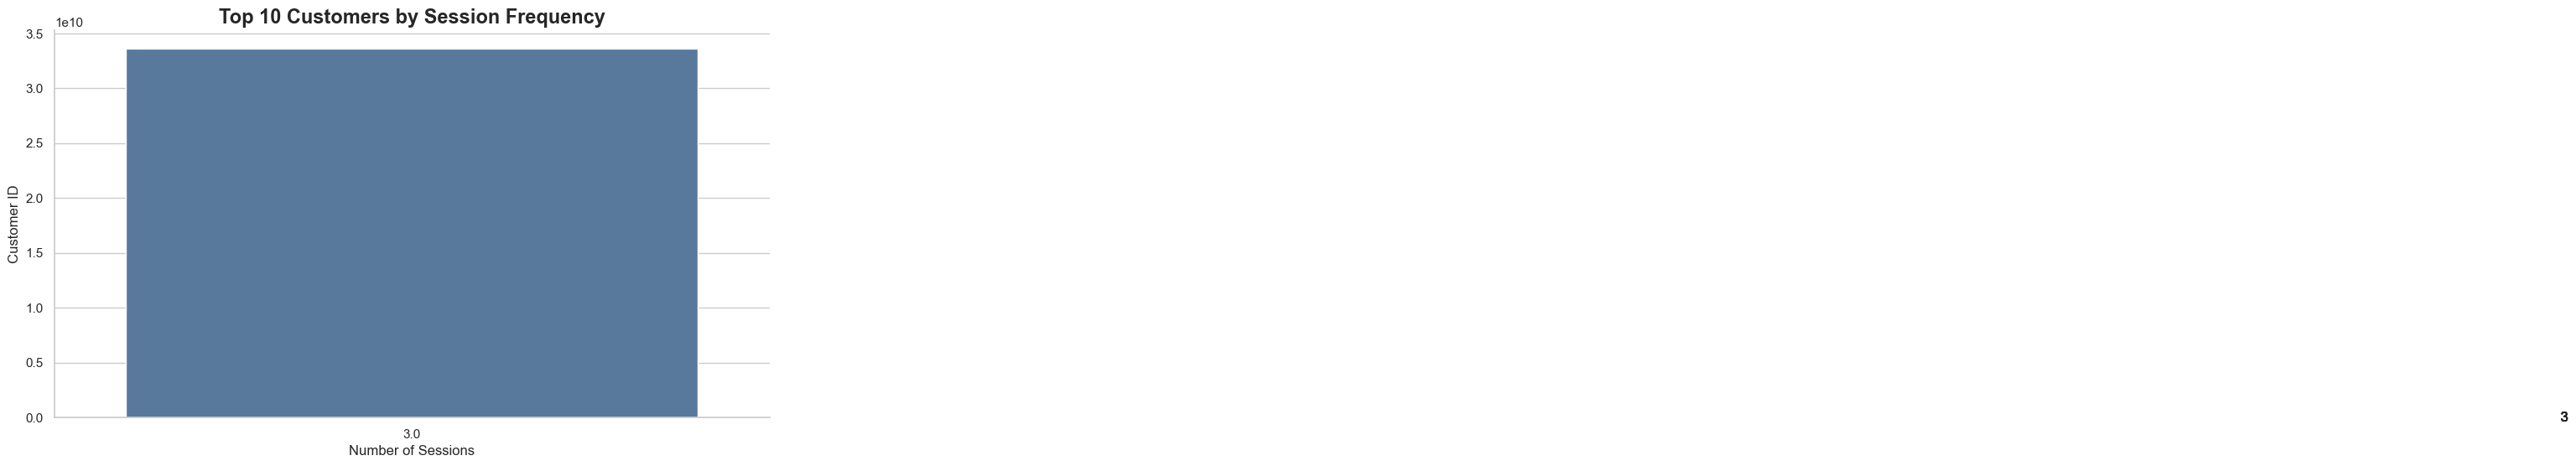

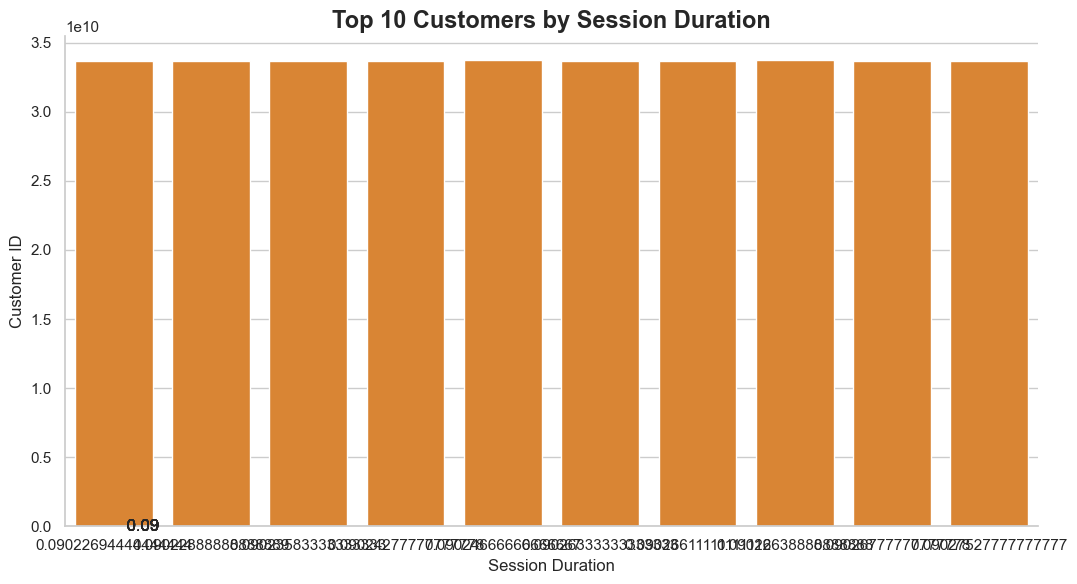

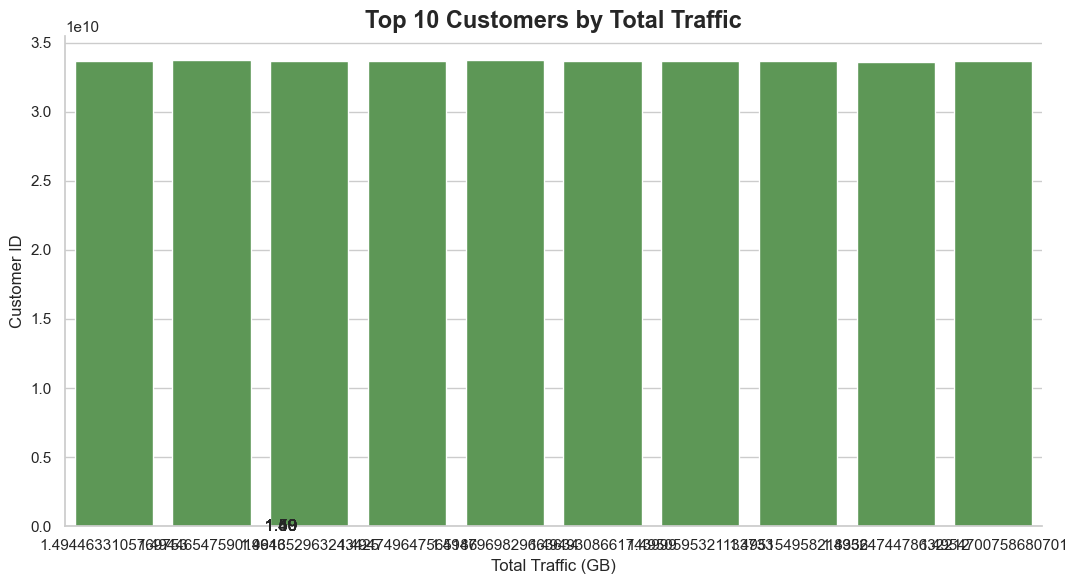

In [68]:
sns.set_theme(style="whitegrid")

# Store the top 10 DataFrames
top10_data = {
    "Session_Frequency": top10_frequency,
    "Session_Duration": top10_duration,
    "Total_Traffic": top10_traffic
}

# Different color for each graph
colors = {
    "Session_Frequency": "#4C78A8",  # Blue
    "Session_Duration": "#F58518",   # Orange
    "Total_Traffic": "#54A24B"       # Green
}

titles = {
    "Session_Frequency": "Top 10 Customers by Session Frequency",
    "Session_Duration": "Top 10 Customers by Session Duration",
    "Total_Traffic": "Top 10 Customers by Total Traffic"
}

x_labels = {
    "Session_Frequency": "Number of Sessions",
    "Session_Duration": "Session Duration",
    "Total_Traffic": "Total Traffic (GB)"
}

for feature, data in top10_data.items():

    plot_data = data.sort_values(feature)

    plt.figure(figsize=(11, 6))

    ax = sns.barplot(
        data=plot_data,
        x=feature,
        y="MSISDN/Number",
        color=colors[feature]   # Different color for each graph
    )

    plt.title(
        titles[feature],
        fontsize=17,
        fontweight="bold"
    )

    plt.xlabel(x_labels[feature])
    plt.ylabel("Customer ID")

    # Add values to bars
    for i, value in enumerate(plot_data[feature]):

        if feature == "Session_Frequency":
            label = f" {value:,.0f}"
        else:
            label = f" {value:,.2f}"

        ax.text(
            value,
            i,
            label,
            va="center"
        )

    sns.despine()
    plt.tight_layout()
    plt.show()

In [100]:
set(top10_frequency["MSISDN/Number"]) & \
set(top10_duration["MSISDN/Number"]) & \
set(top10_traffic["MSISDN/Number"])

set()

### Insights
+ The intersection analysis identifies five customers that consistently appear among the top 10 for session frequency, session duration, and total traffic. This indicates that these customers exhibit high engagement across multiple dimensions rather than being highly active in only one metric. Four identified customers—33614892860, 33625779332, 33626320676, and 33760536639—show consistently high usage, while the Unknown record appears across all three rankings and should be interpreted cautiously due to its exceptionally high values.

## Normalize the Engagement Metrics

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_engagement = scaler.fit_transform(
    engagement_clean[engagement_metrics]
)

In [71]:
X_engagement[:5]

array([[-0.54931532,  0.03455714,  0.79400446],
       [-0.54931532,  0.98737921, -1.37650237],
       [-0.54931532,  0.30409752, -0.0561317 ],
       [-0.54931532, -0.95270892, -0.57827524],
       [ 1.32921036, -1.14138275,  2.53418552]])

### Observation
The engagement metrics were standardized before clustering because session frequency, session duration, and total traffic are measured on different scales. Standardization ensures that each metric contributes comparably to the K-Means distance calculation.

## K-Means with k=3

In [72]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

engagement_clean["Engagement_Cluster"] = kmeans.fit_predict(
    X_engagement
)

In [73]:
engagement_clean["Engagement_Cluster"].value_counts().sort_index()

Engagement_Cluster
0    57825
1    24450
2    24582
Name: count, dtype: int64

### Interpretation
K-Means clustering divided the customers into three engagement groups. Cluster 0 is the dominant segment, containing 57,825 customers, while Cluster 2 contains 24,582 customers. Cluster 1 contains 24,450 customers. The clustering therefore reveals one large common-engagement group and two almost similar engagement groups.

## Cluster Statistics Summary

In [74]:
cluster_summary = engagement_clean.groupby(
    "Engagement_Cluster"
).agg(
    Frequency_Min=("Session_Frequency", "min"),
    Frequency_Max=("Session_Frequency", "max"),
    Frequency_Avg=("Session_Frequency", "mean"),
    Frequency_Total=("Session_Frequency", "sum"),

    Duration_Min=("Session_Duration", "min"),
    Duration_Max=("Session_Duration", "max"),
    Duration_Avg=("Session_Duration", "mean"),
    Duration_Total=("Session_Duration", "sum"),

    Traffic_Min=("Total_Traffic", "min"),
    Traffic_Max=("Total_Traffic", "max"),
    Traffic_Avg=("Total_Traffic", "mean"),
    Traffic_Total=("Total_Traffic", "sum"),

    Customer_Count=("MSISDN/Number", "count")
).reset_index()

cluster_summary

,Engagement_Cluster,Frequency_Min,Frequency_Max,Frequency_Avg,Frequency_Total,Duration_Min,Duration_Max,Duration_Avg,Duration_Total,Traffic_Min,Traffic_Max,Traffic_Avg,Traffic_Total,Customer_Count
0,0,1.000000,2.0,1.033447,59759.074688,0.001984,0.034131,0.019294,1115.699266,0.030966,0.953470,0.468462,27088.843298,57825
1,1,1.292418,3.0,2.167894,53005.003407,0.005065,0.090275,0.044990,1099.995350,0.264699,1.495470,0.933486,22823.728667,24450
2,2,1.000000,2.0,1.030830,25339.866281,0.033140,0.090268,0.047978,1179.399786,0.031270,0.973505,0.457846,11254.763815,24582


### Insight
+ The clustering analysis identifies three distinct customer engagement segments. Cluster 0 is the largest segment, comprising approximately 54% of customers, and represents relatively low-engagement users. Cluster 1 accounts for approximately 23% of customers and represents highly active users characterized by frequent sessions, longer session durations, and higher traffic consumption. Cluster 2 also contains approximately 23% of customers and represents users who have fewer sessions but tend to remain active for longer periods.

In [75]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=engagement_metrics
)

cluster_centers

,Session_Frequency,Session_Duration,Total_Traffic
0,-0.486542,-0.662787,-0.335936
1,1.644616,0.702755,1.165830
2,-0.491201,0.863398,-0.369347


### Insight
+ Cluster 0 represents low-activity users, Cluster 1 represents highly active users with frequent sessions and high traffic consumption, while Cluster 2 represents users who have fewer sessions but tend to stay connected for longer periods.

In [76]:
cluster_centers["Overall_Engagement"] = (
    cluster_centers["Session_Frequency"] +
    cluster_centers["Session_Duration"] +
    cluster_centers["Total_Traffic"]
) / 3

cluster_centers

,Session_Frequency,Session_Duration,Total_Traffic,Overall_Engagement
0,-0.486542,-0.662787,-0.335936,-0.495088
1,1.644616,0.702755,1.165830,1.171067
2,-0.491201,0.863398,-0.369347,0.000950


In [77]:
cluster_rank = (
    cluster_centers["Overall_Engagement"]
    .rank(method="first")
)

cluster_labels = {}

for cluster, rank in cluster_rank.items():
    
    if rank == 1:
        cluster_labels[cluster] = "Low Engagement"
        
    elif rank == 2:
        cluster_labels[cluster] = "Medium Engagement"
        
    else:
        cluster_labels[cluster] = "High Engagement"

In [78]:
engagement_clean["Engagement_Level"] = (
    engagement_clean["Engagement_Cluster"]
    .map(cluster_labels)
)

In [79]:
cluster_centers["Engagement_Level"] = (
    cluster_centers.index.map(cluster_labels)
)

cluster_centers

,Session_Frequency,Session_Duration,Total_Traffic,Overall_Engagement,Engagement_Level
0,-0.486542,-0.662787,-0.335936,-0.495088,Low Engagement
1,1.644616,0.702755,1.165830,1.171067,High Engagement
2,-0.491201,0.863398,-0.369347,0.000950,Medium Engagement


### Insights
+ Cluster 0 represents users with consistently low activity across all three behavioral measures.
+ Cluster 1 represents the most active users, with substantially higher frequency, duration, and traffic consumption.
+ Cluster 2 is an interesting segment because long session duration does not necessarily translate into high traffic or frequent sessions.
+ The clustering therefore captures different dimensions of engagement, rather than simply separating users based on one metric.
+ Overall_Engagement effectively summarizes the behavioral pattern: negative for Cluster 0, strongly positive for Cluster 1, and approximately neutral for Cluster 2.

## Clusters Comparison Plot

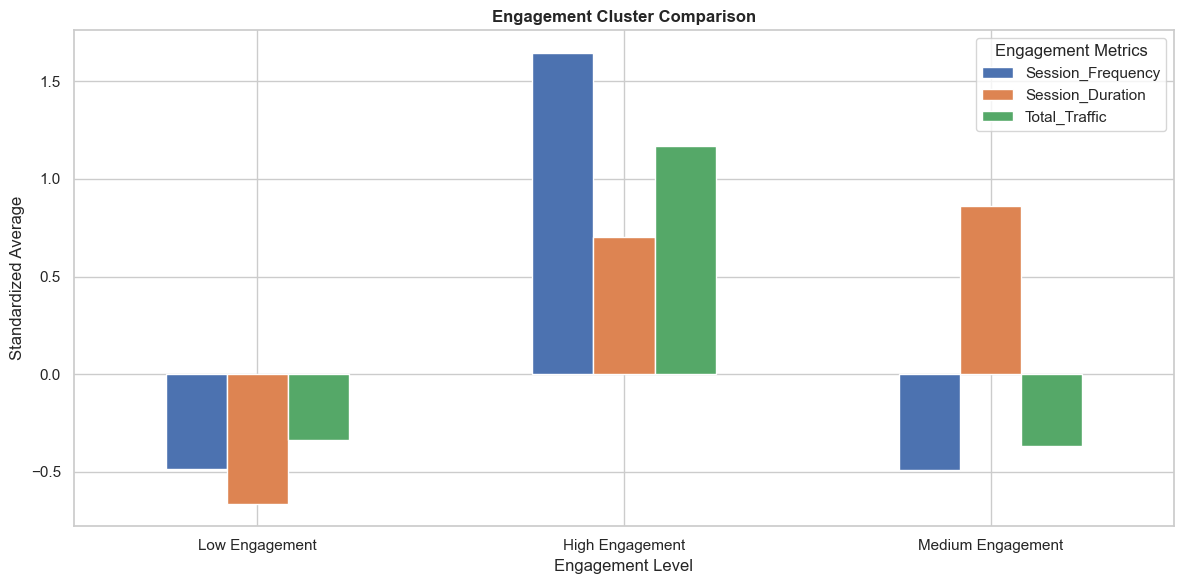

In [80]:
plot_data = cluster_centers.set_index(
    "Engagement_Level"
)[engagement_metrics]

plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Engagement Cluster Comparison")
plt.xlabel("Engagement Level")
plt.ylabel("Standardized Average")
plt.xticks(rotation=0)
plt.legend(title="Engagement Metrics")
plt.tight_layout()
plt.show()

### Insights
+ The engagement cluster comparison reveals three distinct customer usage patterns. High Engagement customers demonstrate above-average session frequency, session duration, and total traffic, indicating intensive service usage.
+ Low Engagement customers show below-average values across all metrics, reflecting relatively limited activity.
+ Medium Engagement customers have longer-than-average session durations but lower session frequency and total traffic, suggesting that they spend more time per session but use services less frequently.
+ These clusters help distinguish customers based on their usage behavior and provide a basis for targeted customer engagement strategies.

## Clusters Visualization

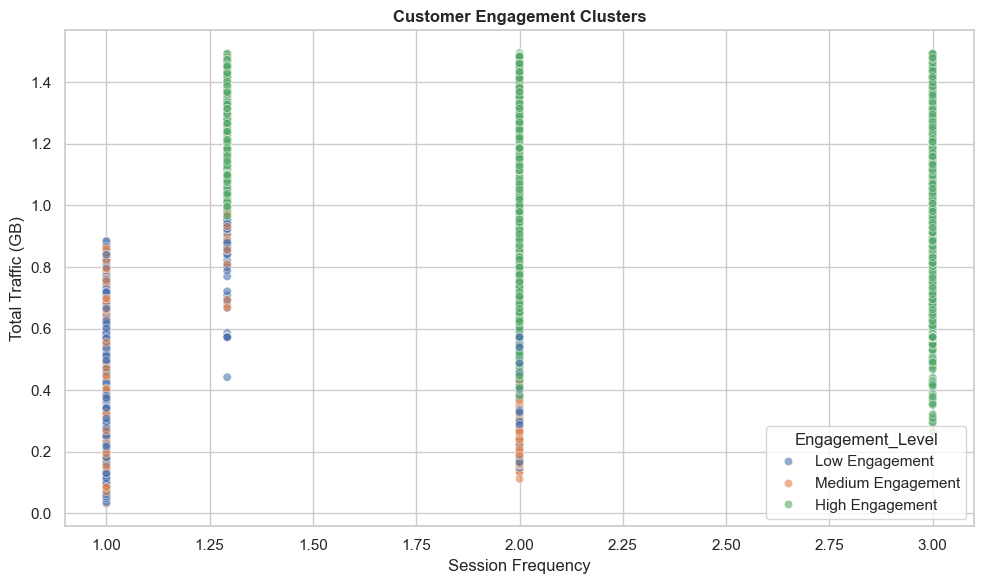

In [81]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=engagement_clean,
    x="Session_Frequency",
    y="Total_Traffic",
    hue="Engagement_Level",
    alpha=0.6
)

plt.title("Customer Engagement Clusters")
plt.xlabel("Session Frequency")
plt.ylabel("Total Traffic (GB)")
plt.tight_layout()
plt.show()

### Insights
+ Low Engagement (Blue): These customers are mainly concentrated around lower session frequencies, particularly 1 session. Their total traffic varies, but many have relatively low traffic usage.
+ Medium Engagement (Orange): These customers are also concentrated around lower session frequencies, mostly 1 or 2 sessions, and generally show low to moderate traffic usage.
+ High Engagement (Green): These customers are mainly distributed across session frequencies of 2 and 3, with a wider range of traffic usage. Some show considerably higher traffic than customers in the other groups.
+ Overlap between clusters: There is visible overlap between Low and Medium Engagement customers, indicating that these groups are not clearly separated using only session frequency and total traffic in this two-dimensional plot.

## Application Level Engagement

In [82]:
app_features = [
    "Social_Media_GB",
    "Google_GB",
    "Email_GB",
    "YouTube_GB",
    "Netflix_GB",
    "Gaming_GB",
    "Other_GB"
]

### Aggregate Application Traffic per User

In [83]:
app_traffic = (
    user_df.groupby("MSISDN/Number")[app_features]
      .sum()
      .reset_index()
)

app_traffic.head()

,MSISDN/Number,Social_Media_GB,Google_GB,Email_GB,YouTube_GB,Netflix_GB,Gaming_GB,Other_GB
0,33601001722.0,0.002079,0.004088,0.001240,0.020139,0.025314,0.756661,0.360022
1,33601001754.0,0.002478,0.004968,0.003081,0.011578,0.010451,0.111526,0.262363
2,33601002511.0,0.002976,0.003207,0.002985,0.019868,0.018025,0.501822,0.467239
3,33601007832.0,0.000261,0.009014,0.002128,0.006498,0.001809,0.364265,0.032857
4,33601008617.0,0.002713,0.017229,0.003078,0.038681,0.045823,1.224501,0.749533


#### Insight
+ The application-level aggregation provides the total traffic consumed by each user across different applications. The displayed users show varying patterns of application usage, with Gaming and Other applications contributing relatively larger amounts of traffic for several users.
+ For example, customer 33601008617 shows the highest Gaming traffic among the displayed records at approximately 1.2245 GB, followed by 0.7495 GB of Other traffic.
+ This aggregated dataset can now be used to rank users within each application and identify the top 10 most engaged users for Social Media, Google, Email, YouTube, Netflix, Gaming, and Other applications.

### Top 10 Users for Every Application

In [84]:
app_traffic_valid = app_traffic[
    app_traffic["MSISDN/Number"] != "Unknown"
].copy()

top_10_app_users = {}

for app in app_features:
    
    top_10 = (
        app_traffic_valid[["MSISDN/Number", app]]
        .sort_values(by=app, ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    
    top_10_app_users[app] = top_10
    
    print(f"\nTop 10 users for {app}")
    print(top_10)


Top 10 users for Social_Media_GB
   MSISDN/Number  Social_Media_GB
0  33626320676.0         0.040396
1  33760536639.0         0.037051
2  33659725664.0         0.032980
3  33614892860.0         0.026351
4  33625779332.0         0.025272
5  33667163239.0         0.022583
6  33786323068.0         0.022328
7  33669068942.0         0.022166
8  33603127838.0         0.021493
9  33658490784.0         0.021420

Top 10 users for Google_GB
   MSISDN/Number  Google_GB
0  33626320676.0   0.141740
1  33625779332.0   0.132535
2  33614892860.0   0.119185
3  33760536639.0   0.114760
4  33659725664.0   0.108514
5  33786323068.0   0.102682
6  33675877202.0   0.102316
7  33667163239.0   0.097819
8  33761268199.0   0.090422
9  33698756430.0   0.085621

Top 10 users for Email_GB
   MSISDN/Number  Email_GB
0  33626320676.0  0.039506
1  33614892860.0  0.037987
2  33625779332.0  0.037843
3  33786323068.0  0.033816
4  33659725664.0  0.033527
5  33760536639.0  0.031380
6  33675877202.0  0.029350
7  3366546054

In [85]:
top_10_all_apps = []

for app in app_features:
    
    top_10 = (
        app_traffic_valid[["MSISDN/Number", app]]
        .sort_values(by=app, ascending=False)
        .head(10)
        .copy()
    )
    
    top_10["Application"] = app
    top_10.rename(columns={app: "Total_Traffic_GB"}, inplace=True)
    
    top_10_all_apps.append(top_10)

top_10_all_apps = pd.concat(
    top_10_all_apps,
    ignore_index=True
)

top_10_all_apps

,MSISDN/Number,Total_Traffic_GB,Application
0,33626320676.0,0.040396,Social_Media_GB
1,33760536639.0,0.037051,Social_Media_GB
2,33659725664.0,0.032980,Social_Media_GB
3,33614892860.0,0.026351,Social_Media_GB
4,33625779332.0,0.025272,Social_Media_GB
...,...,...,...
65,33659725664.0,5.883552,Other_GB
66,33626948251.0,4.941083,Other_GB
67,33627080969.0,4.766314,Other_GB
68,33761268199.0,4.729051,Other_GB


#### Insights
+ Gaming is one of the major contributors to application-level traffic among the highest-usage customers, with the top identified users consuming more than 6 GB each. The highest identified Gaming user consumed approximately 7.22 GB, followed by 6.95 GB and 6.82 GB.
+ The Other application category also contributes substantial traffic, with several top users exceeding 5 GB of usage. This indicates that significant traffic comes from applications outside the specifically identified categories.
+ YouTube and Netflix have relatively high usage among entertainment applications. Several customers consistently appear among the highest users of both YouTube and Netflix, suggesting that some customers have a strong preference for video-streaming services.
+ Several customers consistently appear among the top users across multiple application categories. This indicates that some customers have broad and intensive data usage across different types of services rather than concentrating their activity on a single application.
+ Compared with Gaming and Other applications, Social Media and Email contribute relatively lower traffic among the highest-usage users, indicating that these applications are less data-intensive in terms of total traffic consumption.

In [86]:
top_10_with_engagement = top_10_all_apps.merge(
    engagement_clean[
        [
            "MSISDN/Number",
            "Session_Frequency",
            "Session_Duration",
            "Total_Traffic",
            "Engagement_Cluster",
            "Engagement_Level"
        ]
    ],
    on="MSISDN/Number",
    how="left"
)

top_10_with_engagement

,MSISDN/Number,Total_Traffic_GB,Application,Session_Frequency,Session_Duration,Total_Traffic,Engagement_Cluster,Engagement_Level
0,33626320676.0,0.040396,Social_Media_GB,1.292418,0.031772,0.572422,0,Low Engagement
1,33760536639.0,0.037051,Social_Media_GB,1.292418,0.031772,0.572422,0,Low Engagement
2,33659725664.0,0.032980,Social_Media_GB,1.292418,0.031772,0.572422,0,Low Engagement
3,33614892860.0,0.026351,Social_Media_GB,1.292418,0.031772,0.572422,0,Low Engagement
4,33625779332.0,0.025272,Social_Media_GB,1.292418,0.031772,0.572422,0,Low Engagement
...,...,...,...,...,...,...,...,...
65,33659725664.0,5.883552,Other_GB,1.292418,0.031772,0.572422,0,Low Engagement
66,33626948251.0,4.941083,Other_GB,1.292418,0.031772,0.572422,0,Low Engagement
67,33627080969.0,4.766314,Other_GB,1.292418,0.031772,0.572422,0,Low Engagement
68,33761268199.0,4.729051,Other_GB,1.292418,0.031772,0.572422,0,Low Engagement


+ Application-level analysis identified the top 10 users based on total traffic consumption for each application. These users were then linked with their overall engagement levels. The distribution of engagement levels across applications helps identify whether heavy application users are also highly engaged overall. Additionally, users appearing in multiple application-level Top 10 lists can be identified as customers with broad and intensive application usage.

## Top 3 Most Used Applications

In [87]:
app_usage = (
    user_df[app_features]
    .sum()
    .sort_values(ascending=False)
)

app_usage

Gaming_GB          60116.839694
Other_GB           59981.645590
YouTube_GB          3163.257982
Netflix_GB          3161.179815
Google_GB           1090.666449
Email_GB             315.592947
Social_Media_GB      255.403604
dtype: float64

In [88]:
top3_apps = app_usage.head(3)

top3_apps

Gaming_GB     60116.839694
Other_GB      59981.645590
YouTube_GB     3163.257982
dtype: float64

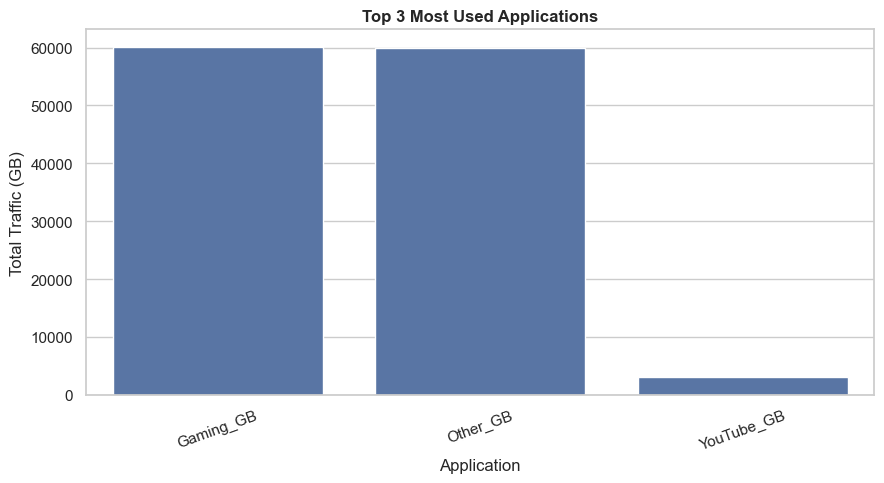

In [89]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=top3_apps.index,
    y=top3_apps.values
)

plt.title("Top 3 Most Used Applications")
plt.xlabel("Application")
plt.ylabel("Total Traffic (GB)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Insights
+ The top three applications account for the largest share of total application traffic, indicating that these services are major contributors to customer data consumption.
+ Application-level traffic analysis shows that Gaming and Other are the two most-used application categories, generating approximately 60,116.84 GB and 59,981.65 GB of traffic, respectively.
+ Their traffic volumes are very close, indicating that both categories are major contributors to overall data consumption.
+ YouTube ranks third with approximately 3,163.26 GB, which is substantially lower than the traffic generated by Gaming and Other. This indicates that data usage is heavily concentrated in Gaming and the Other application category.

## Elbow Method

In [90]:
inertia = []

K = range(2, 11)

for k in K:
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_engagement)
    
    inertia.append(model.inertia_)

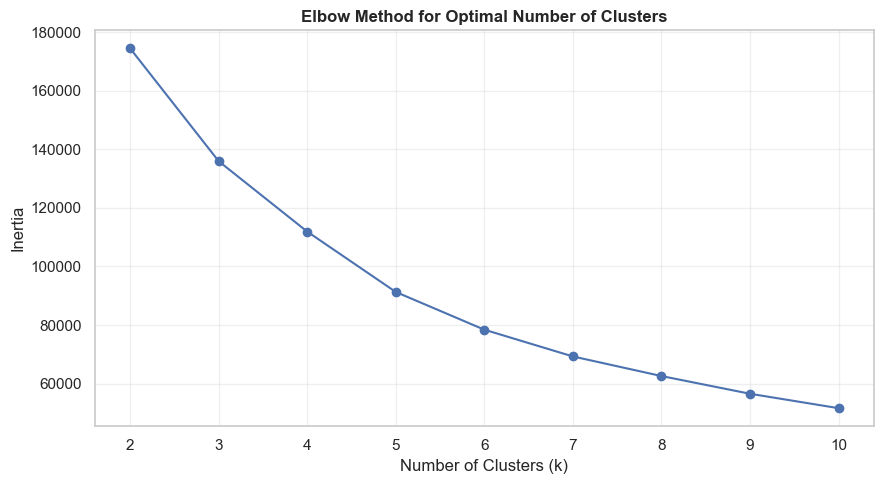

In [91]:
plt.figure(figsize=(9, 5))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.xticks(K)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Insight
+ k = 5
The curve starts to flatten around 5 clusters, making it a reasonable candidate for the optimized number of clusters. However, the elbow is not sharply defined, so k = 5 is an approximate choice rather than a definitive optimum.
+ The Elbow Method was used to identify a suitable number of clusters for customer engagement segmentation. The plot shows a substantial decrease in inertia as the number of clusters increases from 2 to 5. Beyond 5 clusters, the reduction in inertia becomes more gradual, indicating diminishing improvements in clustering.

The curve begins to flatten around k = 5, suggesting that five clusters may provide a reasonable balance between cluster compactness and model complexity. However, the elbow is not sharply defined, so this value should be considered an approximate choice.

## Final User Engagement Dataset

In [92]:
engagement_columns = [
    "MSISDN/Number",
    "Session_Frequency",
    "Session_Duration",
    "Total_Traffic",
    "Engagement_Cluster",
    "Engagement_Level"
]

task2_engagement = engagement_clean[engagement_columns].copy()

In [93]:
app_columns = [
    "MSISDN/Number",
    "Social_Media_GB",
    "Google_GB",
    "Email_GB",
    "YouTube_GB",
    "Netflix_GB",
    "Gaming_GB",
    "Other_GB"
]

app_usage_df = user_df[app_columns].copy()

In [96]:
task2_df = task2_engagement.merge(
    app_usage_df,
    on="MSISDN/Number",
    how="left",
    validate="one_to_one"
)

print("Shape:", task2_df.shape)
print("Columns:", task2_df.columns.tolist())
print(task2_df["Engagement_Level"].value_counts())

display(task2_df.head())

Shape: (106857, 13)
Columns: ['MSISDN/Number', 'Session_Frequency', 'Session_Duration', 'Total_Traffic', 'Engagement_Cluster', 'Engagement_Level', 'Social_Media_GB', 'Google_GB', 'Email_GB', 'YouTube_GB', 'Netflix_GB', 'Gaming_GB', 'Other_GB']
Engagement_Level
Low Engagement       57825
Medium Engagement    24582
High Engagement      24450
Name: count, dtype: int64


,MSISDN/Number,Session_Frequency,Session_Duration,Total_Traffic,Engagement_Cluster,Engagement_Level,Social_Media_GB,Google_GB,Email_GB,YouTube_GB,Netflix_GB,Gaming_GB,Other_GB
0,33601001722.0,1.0,0.032422,0.818344,0,Low Engagement,0.002079,0.004088,0.001240,0.020139,0.025314,0.756661,0.360022
1,33601001754.0,1.0,0.050342,0.146087,2,Medium Engagement,0.002478,0.004968,0.003081,0.011578,0.010451,0.111526,0.262363
2,33601002511.0,1.0,0.037491,0.555037,2,Medium Engagement,0.002976,0.003207,0.002985,0.019868,0.018025,0.501822,0.467239
3,33601007832.0,1.0,0.013855,0.393317,0,Low Engagement,0.000261,0.009014,0.002128,0.006498,0.001809,0.364265,0.032857
4,33601008617.0,2.0,0.010307,1.357320,1,High Engagement,0.002713,0.017229,0.003078,0.038681,0.045823,1.224501,0.749533


In [97]:
import os

os.makedirs("task2_outputs", exist_ok=True)

# Save as CSV
task2_df.to_csv(
    "task2_outputs/task2_final_customer_engagement.csv",
    index=False
)

# Save as Pickle
task2_df.to_pickle(
    "task2_outputs/task2_final_customer_engagement.pkl"
)

print("Task 2 dataset saved successfully!")

Task 2 dataset saved successfully!


### Cluster Summary & Application Results

In [98]:
cluster_summary.to_csv(
    "task2_outputs/task2_cluster_summary.csv",
    index=False
)

app_usage.to_csv(
    "task2_outputs/task2_application_usage.csv",
    header=["Total_Traffic_GB"]
)

top3_apps.to_csv(
    "task2_outputs/task2_top3_applications.csv",
    header=["Total_Traffic_GB"]
)

### K-Means Model & Scaler

In [99]:
import joblib

model_data = {
    "scaler": scaler,
    "kmeans": kmeans,
    "engagement_metrics": engagement_metrics,
    "cluster_labels": cluster_labels
}

joblib.dump(
    model_data,
    "task2_outputs/engagement_kmeans_model.joblib"
)

['task2_outputs/engagement_kmeans_model.joblib']

## Conclusion from User Engagement Analysis
+ The User Engagement Analysis was conducted to understand how actively customers use the TellCo mobile network and its applications. Customer engagement was evaluated using three key metrics: session frequency, session duration, and total data traffic (download and upload). K-Means clustering was applied to segment customers into Low, Medium, and High Engagement groups based on their usage patterns.

+ The application analysis showed that Gaming and Other applications generated the highest traffic. These findings help TellCo understand customer behaviour, plan network resources, and develop targeted engagement and retention strategies.

+ The Elbow Method indicated that the curve begins to flatten at approximately five clusters, suggesting that a more detailed segmentation may be worth exploring. The three-cluster model was retained for the main engagement analysis to provide the required Low, Medium, and High Engagement groups.

+ Overall, the analysis provides insight into customer usage patterns, identifies highly engaged users, and highlights differences in application consumption. These findings can help TellCo understand customer behaviour, plan network resources, develop relevant customer engagement strategies, and identify opportunities to improve customer retention and service offerings.